##Silahkan buat Final Project kamu disini ☺️

Here is the case

Sebuah universitas menyadari bahwa penurunan nilai akademik mahasiswa seringkali bukan disebabkan oleh kurangnya kemampuan kognitif, melainkan karena manajemen gaya hidup yang kurang seimbang. Banyak mahasiswa kesulitan membagi waktu antara belajar, bekerja paruh waktu, serta hiburan seperti bermain media sosial dan menonton Netflix, yang akhirnya berdampak pada jam tidur dan kesehatan mental mereka. Pihak kampus, melalui biro konseling akademik, ingin mengambil langkah preventif dengan mendeteksi mahasiswa yang berisiko gagal sebelum ujian akhir berlangsung.

Universitas tersebut memiliki dataset yang merangkum rutinitas keseharian mahasiswa, mulai dari durasi belajar, kualitas diet, frekuensi olahraga, hingga kondisi kesehatan mental. Sebagai seorang machine learning engineer, bagaimana Anda akan menggunakan data ini untuk memprediksi nilai ujian akhir (exam score) mahasiswa di masa depan, agar pihak kampus dapat memberikan pendampingan akademik serta rekomendasi gaya hidup yang dipersonalisasi sedini mungkin?


Data Understanding:

- student_id: Nomor identitas unik untuk setiap mahasiswa.
- age: Usia mahasiswa (dalam tahun).
- gender: Jenis kelamin mahasiswa (contoh: Male, Female).
- study_hours_per_day: Rata-rata waktu yang didedikasikan mahasiswa khusus untuk belajar setiap harinya (dalam jam).
- social_media_hours: Rata-rata waktu yang dihabiskan untuk berselancar di media sosial per hari (dalam jam).
- netflix_hours: Rata-rata waktu yang dihabiskan untuk menonton platform streaming (seperti Netflix) per hari (dalam jam).
- part_time_job: Menunjukkan apakah mahasiswa tersebut bekerja paruh waktu (part-time) di luar jam kuliahnya.
- attendance_percentage: Persentase kehadiran mahasiswa di kelas selama satu semester penuh.
- sleep_hours: Rata-rata durasi tidur mahasiswa setiap malamnya (dalam jam).
- diet_quality: Kategori yang menggambarkan kualitas asupan makanan/gizi mahasiswa.
- exercise_frequency: Angka yang menunjukkan seberapa sering mahasiswa berolahraga dalam jangka waktu tertentu (misal: per minggu).
- parental_education_level: Tingkat pendidikan terakhir yang ditempuh oleh orang tua mahasiswa.
- internet_quality: Evaluasi kualitas koneksi internet yang digunakan mahasiswa, yang sangat krusial untuk belajar mandiri.
- mental_health_rating: Skor penilaian mandiri terkait kondisi kesehatan psikologis dan tingkat stres mahasiswa.
- extracurricular_participation: Keterlibatan mahasiswa dalam organisasi atau kegiatan ekstrakurikuler kampus.
- exam_score (Target Variable): Nilai akhir ujian mahasiswa yang diperoleh. Fitur ini akan menjadi label/target yang diprediksi oleh model machine learning.

# **DATA UNDERSTANDING**


1) Data Preparation

In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [119]:
from google.colab import files
uploaded = files.upload()

Saving student_habits_performance.csv to student_habits_performance.csv


In [120]:
df = pd.read_csv('student_habits_performance.csv')

In [121]:
print("=== 5 Data Teratas ===")
display(df.head())

print("\n=== 5 Data Terbawah ===")
display(df.tail())

=== 5 Data Teratas ===


,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4



=== 5 Data Terbawah ===


,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
995,S1995,21,Female,2.6,0.5,1.6,No,77.0,7.5,Fair,2,High School,Good,6,Yes,76.1
996,S1996,17,Female,2.9,1.0,2.4,Yes,86.0,6.8,Poor,1,High School,Average,6,Yes,65.9
997,S1997,20,Male,3.0,2.6,1.3,No,61.9,6.5,Good,5,Bachelor,Good,9,Yes,64.4
998,S1998,24,Male,5.4,4.1,1.1,Yes,100.0,7.6,Fair,0,Bachelor,Average,1,No,69.7
999,S1999,19,Female,4.3,2.9,1.9,No,89.4,7.1,Good,2,Bachelor,Average,8,No,74.9


2) Identifikasi Fitur/Kolom

In [122]:
print("=== STRUKTUR DATASET ===")
print("Jumlah Baris dan Kolom:", df.shape)

print("\nNama Kolom:")
print(df.columns.tolist())

=== STRUKTUR DATASET ===
Jumlah Baris dan Kolom: (1000, 16)

Nama Kolom:
['student_id', 'age', 'gender', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'part_time_job', 'attendance_percentage', 'sleep_hours', 'diet_quality', 'exercise_frequency', 'parental_education_level', 'internet_quality', 'mental_health_rating', 'extracurricular_participation', 'exam_score']


In [123]:
print("\n===== INFO DATASET =====")
df.info()


===== INFO DATASET =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality       

3) Mendeskripsikan Data

In [124]:
print("\n=== STATISTIK DESKRIPTIF ===")
display(df.describe())


=== STATISTIK DESKRIPTIF ===


,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,1000.0000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.4980,3.55010,2.505500,1.819700,84.131700,6.470100,3.042000,5.438000,69.601500
std,2.3081,1.46889,1.172422,1.075118,9.399246,1.226377,2.025423,2.847501,16.888564
min,17.0000,0.00000,0.000000,0.000000,56.000000,3.200000,0.000000,1.000000,18.400000
25%,18.7500,2.60000,1.700000,1.000000,78.000000,5.600000,1.000000,3.000000,58.475000
50%,20.0000,3.50000,2.500000,1.800000,84.400000,6.500000,3.000000,5.000000,70.500000
75%,23.0000,4.50000,3.300000,2.525000,91.025000,7.300000,5.000000,8.000000,81.325000
max,24.0000,8.30000,7.200000,5.400000,100.000000,10.000000,6.000000,10.000000,100.000000


Cek Missing Value

In [125]:
df.isnull().sum()

,0
student_id,0
age,0
gender,0
study_hours_per_day,0
social_media_hours,0
netflix_hours,0
part_time_job,0
attendance_percentage,0
sleep_hours,0
diet_quality,0


Missing value ditemukan pada kolom "parental_education_level" sebanyang 91 baris atau 9.1% dari seluruh baris data.

In [126]:
df.duplicated().sum()

np.int64(0)

4.) Duplicate Row

In [127]:
df_eda = df.copy()
df.duplicated()

print(df.duplicated().sum())

0


Tidak ditemukan duplikat baris pada data

---



# **Visualisasi Data**

## Univariate Analysis

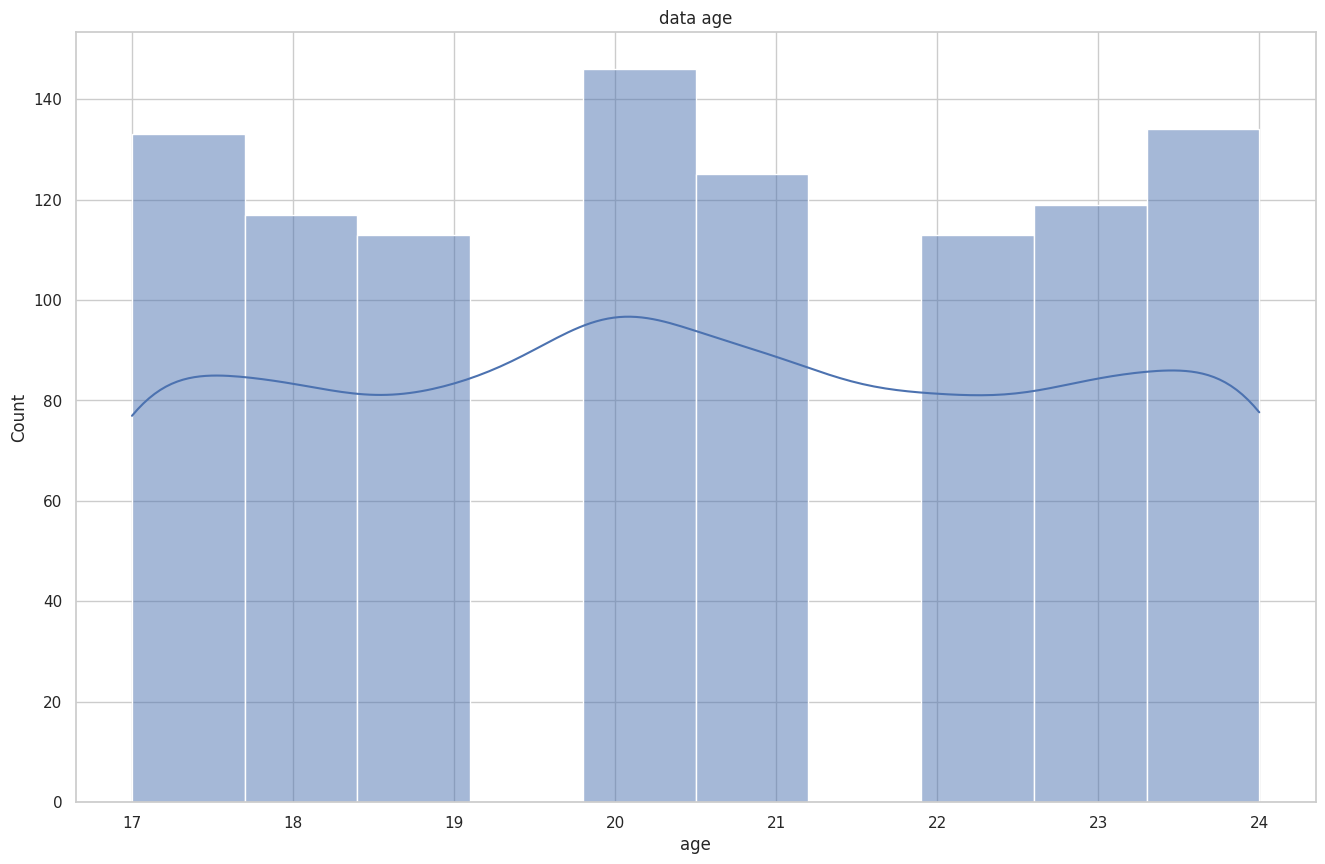

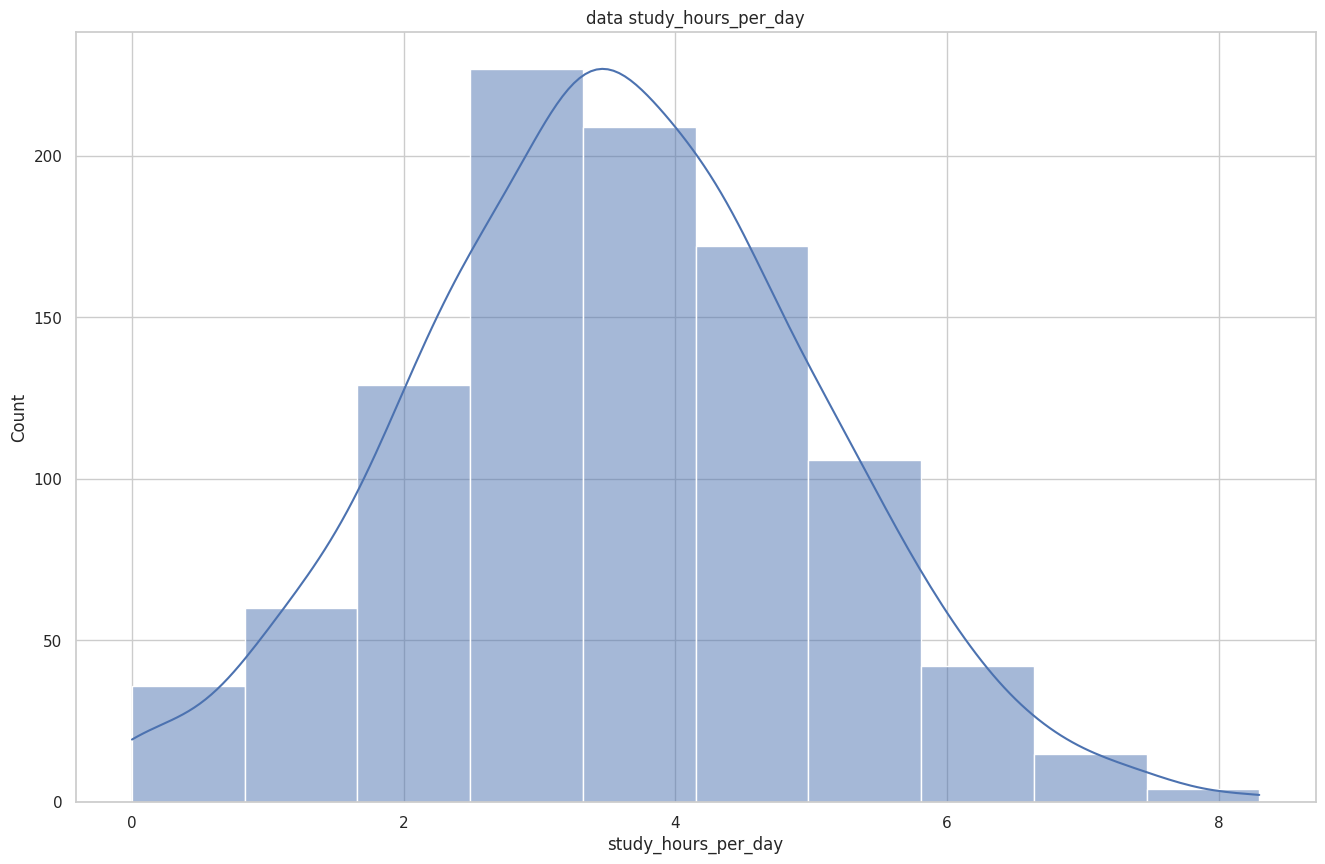

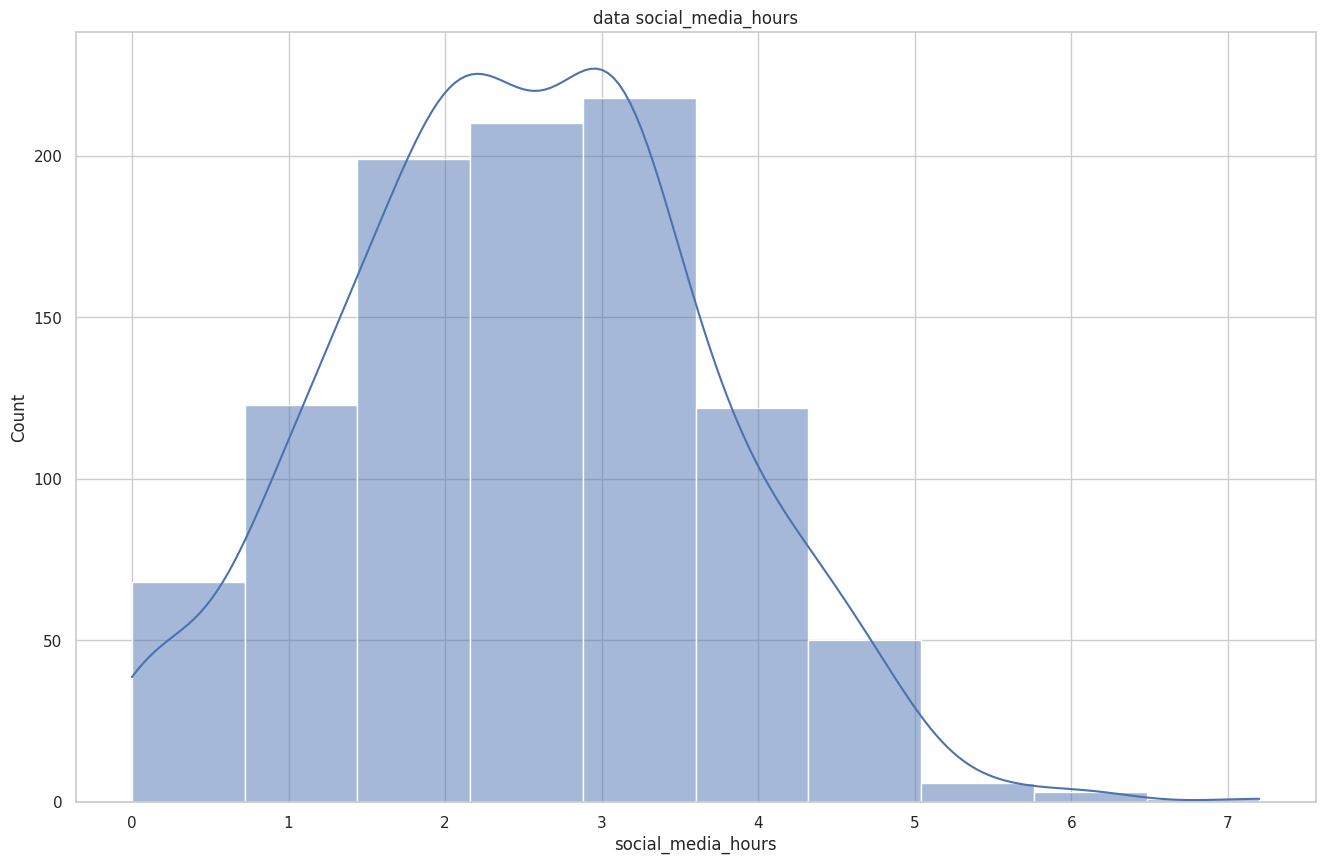

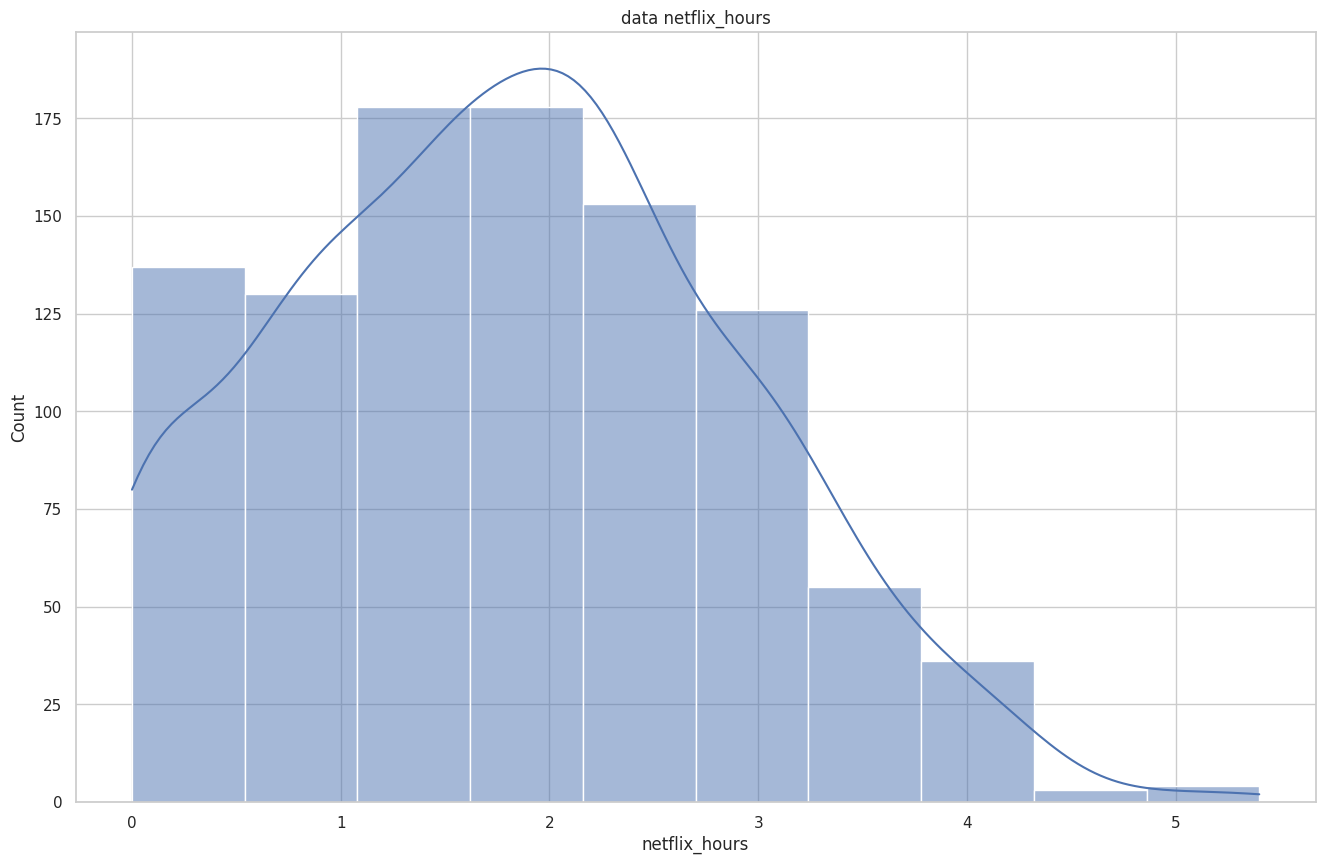

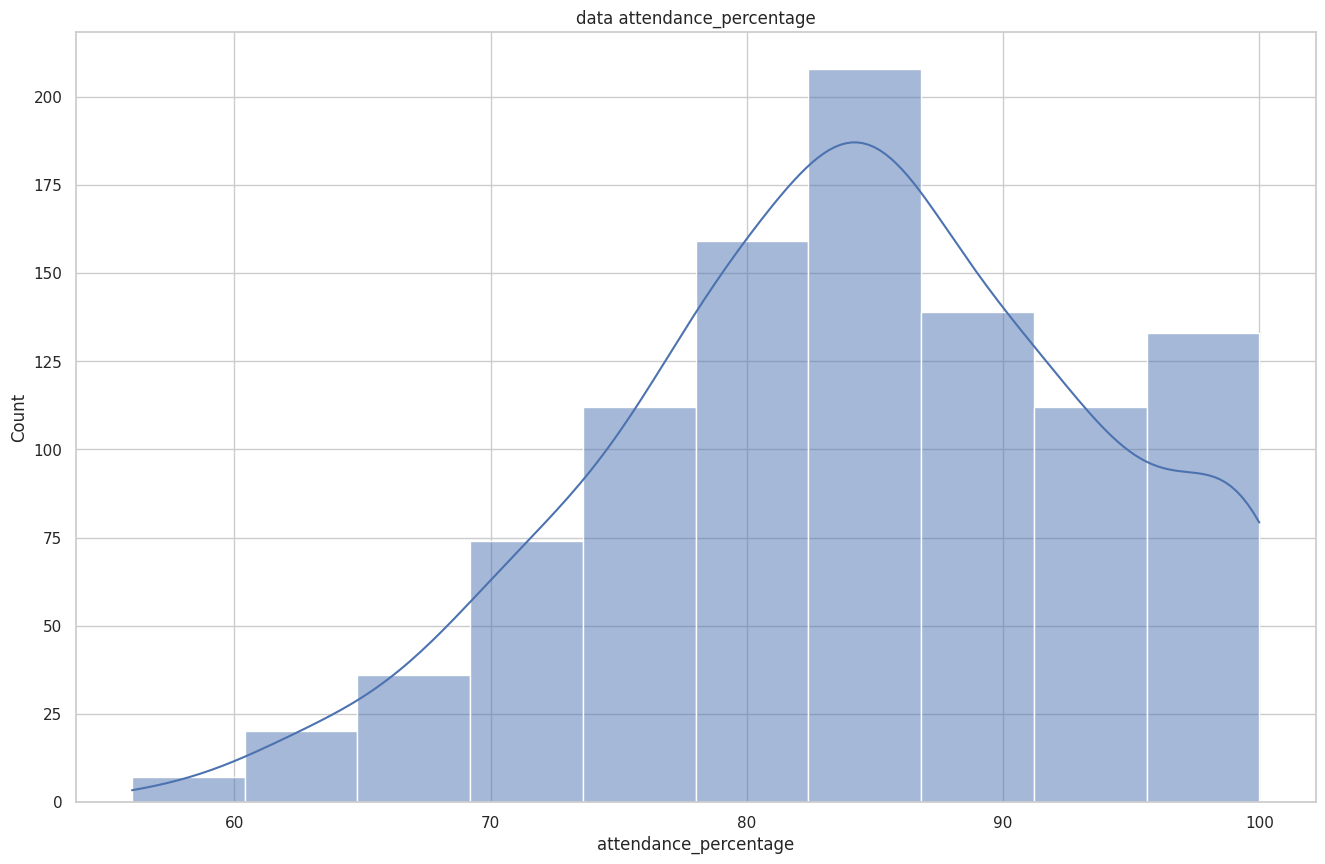

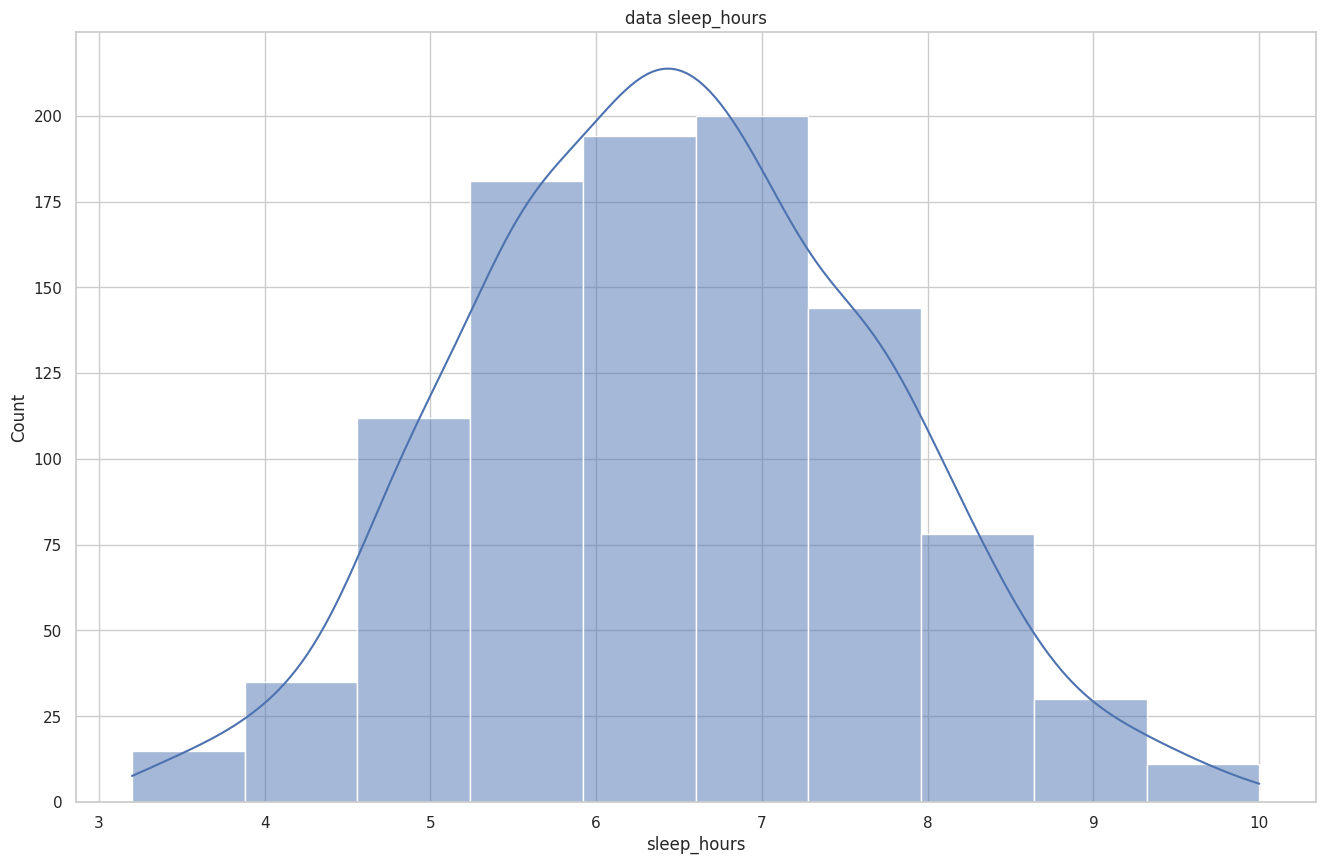

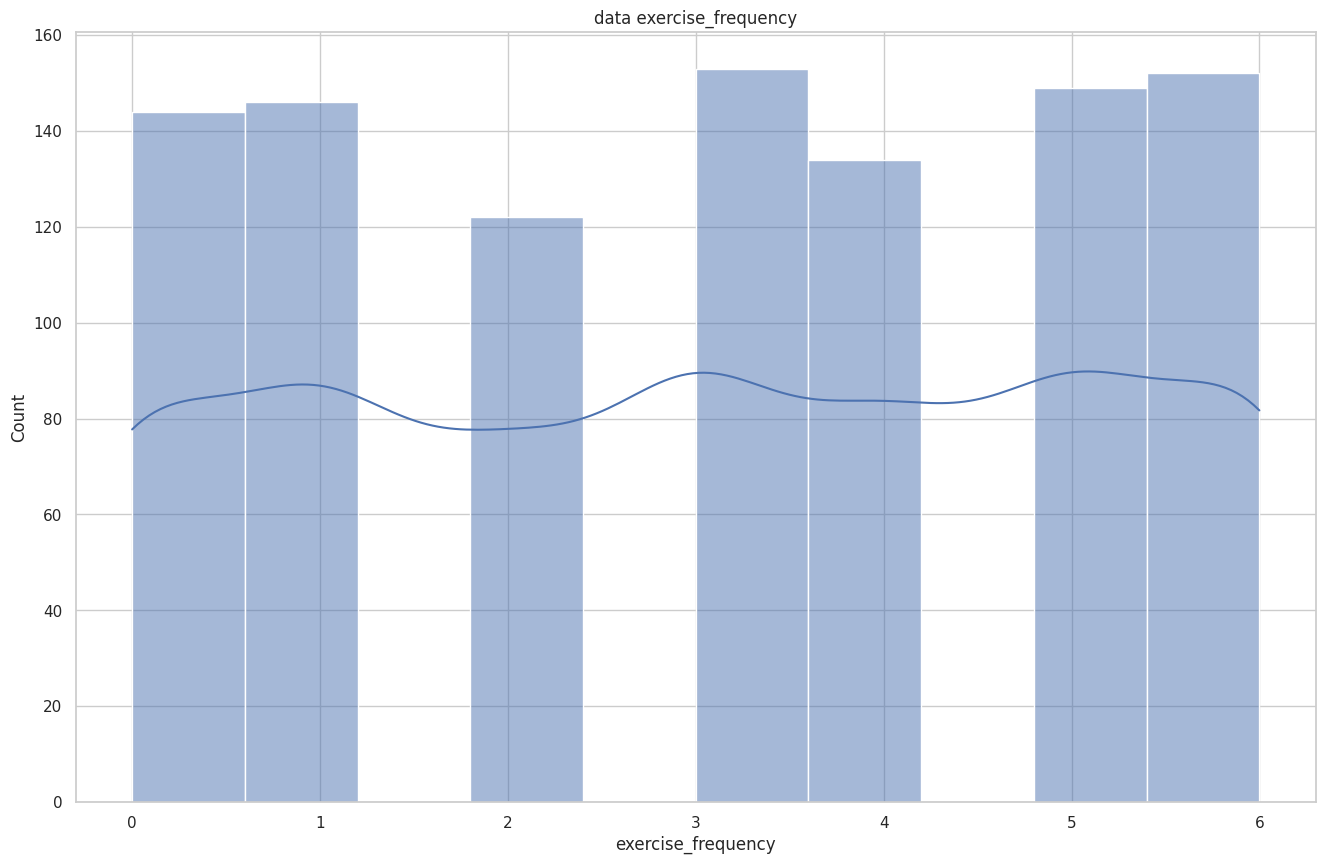

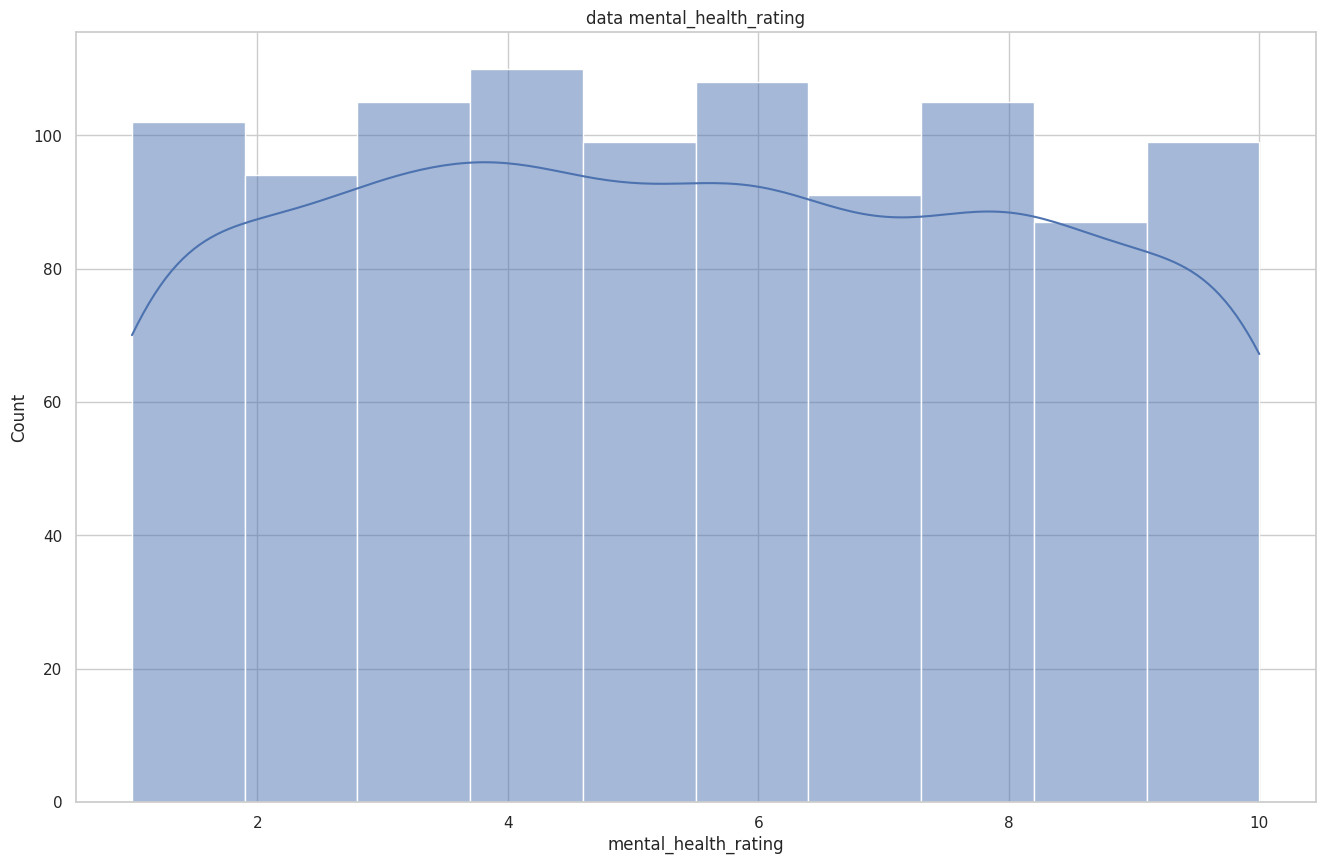

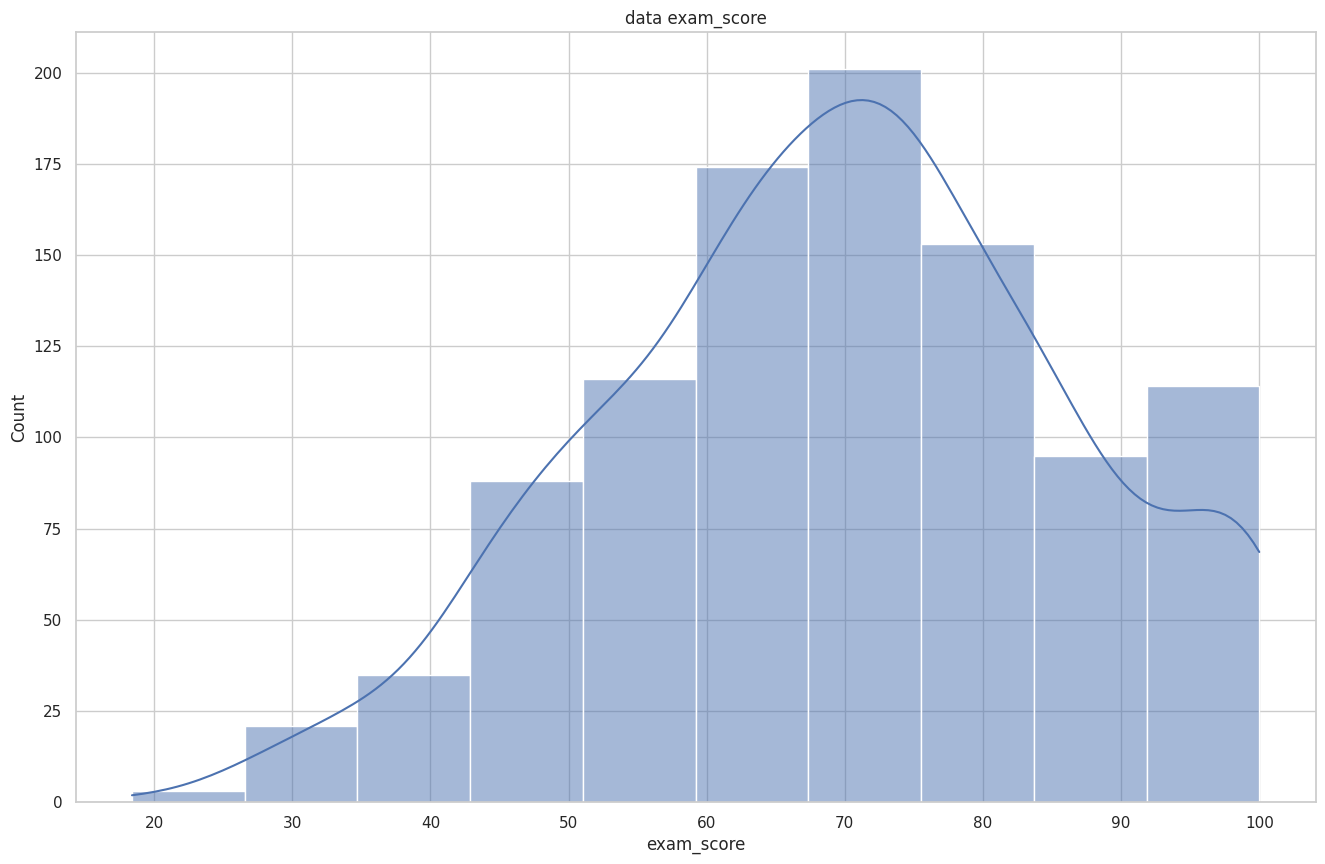

In [128]:
for col in df.select_dtypes(include='number').columns:
  plt.figure(figsize=(16,10))
  sns.histplot(x=df[col],bins= 10,kde=True)
  plt.title(f'data {col}')
  plt.show()

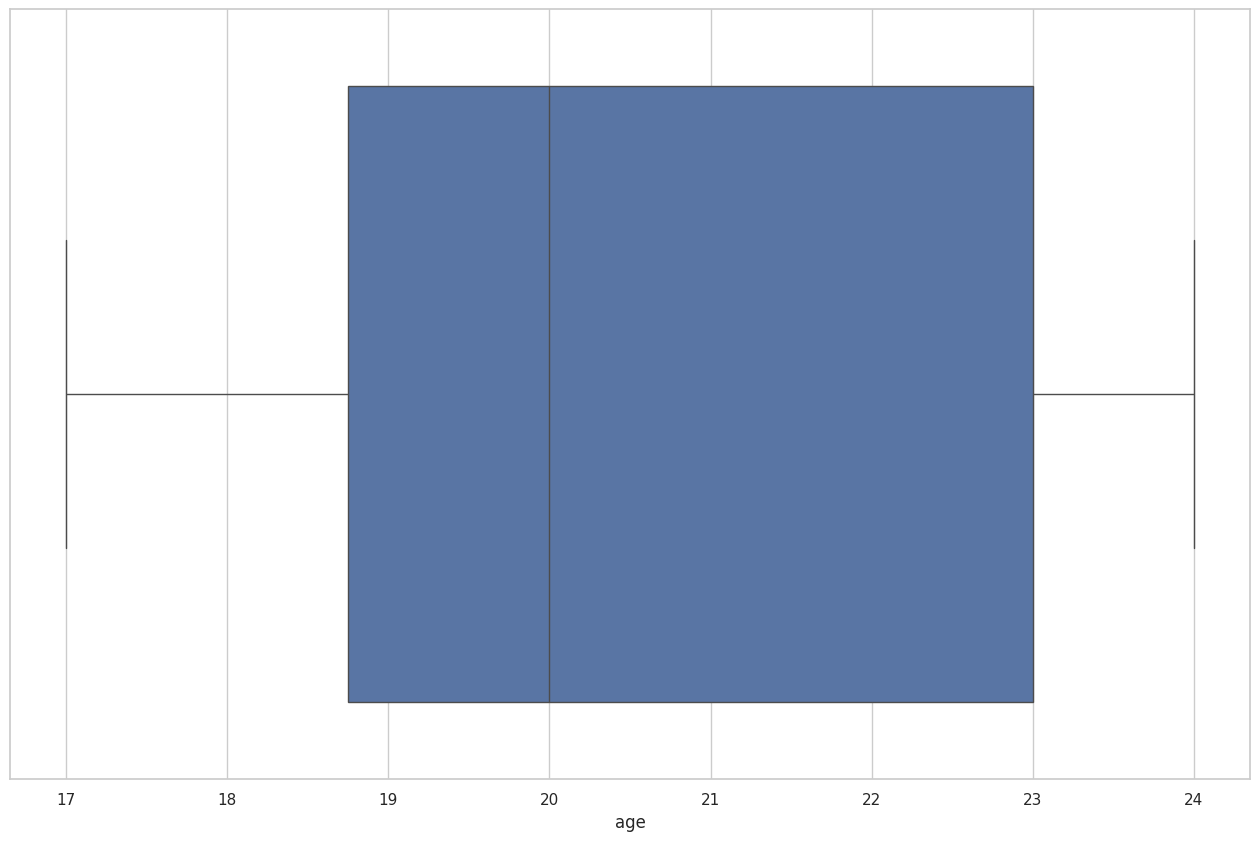

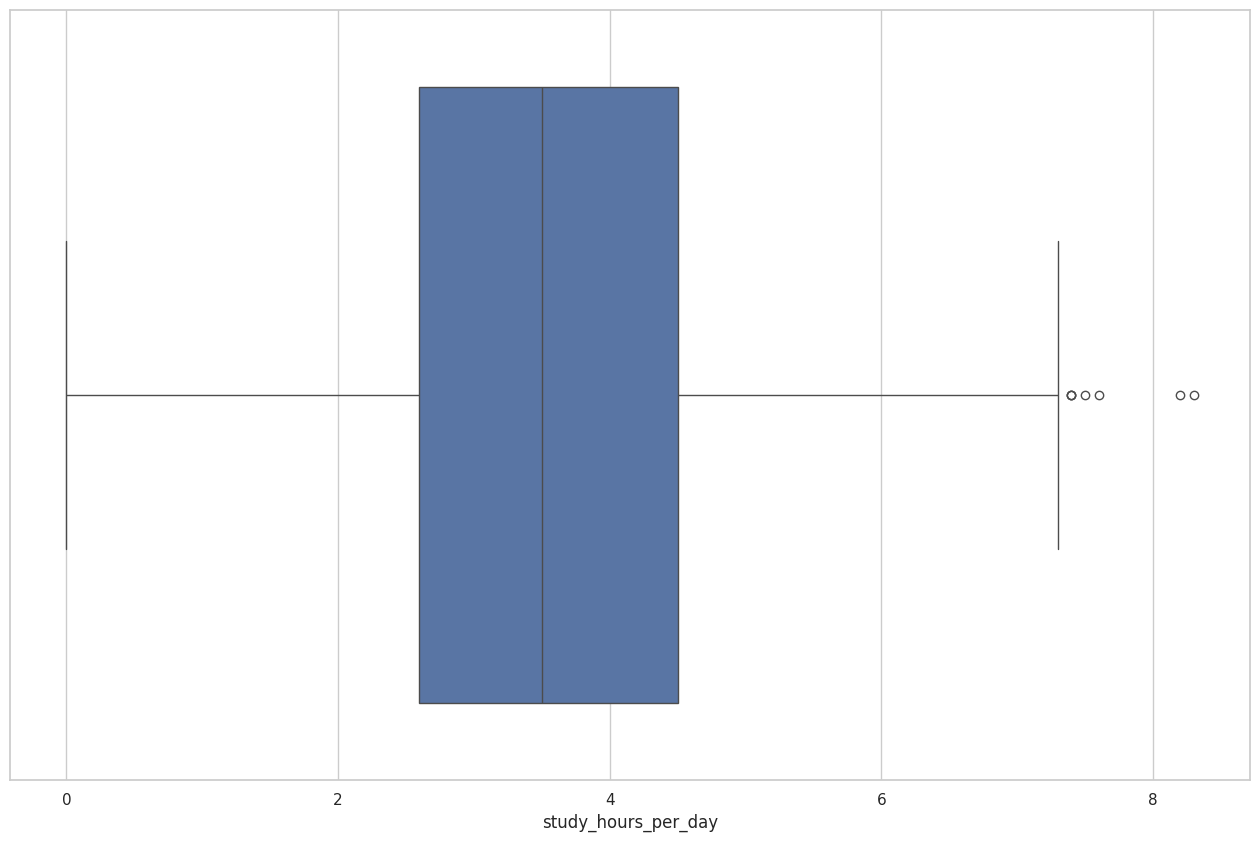

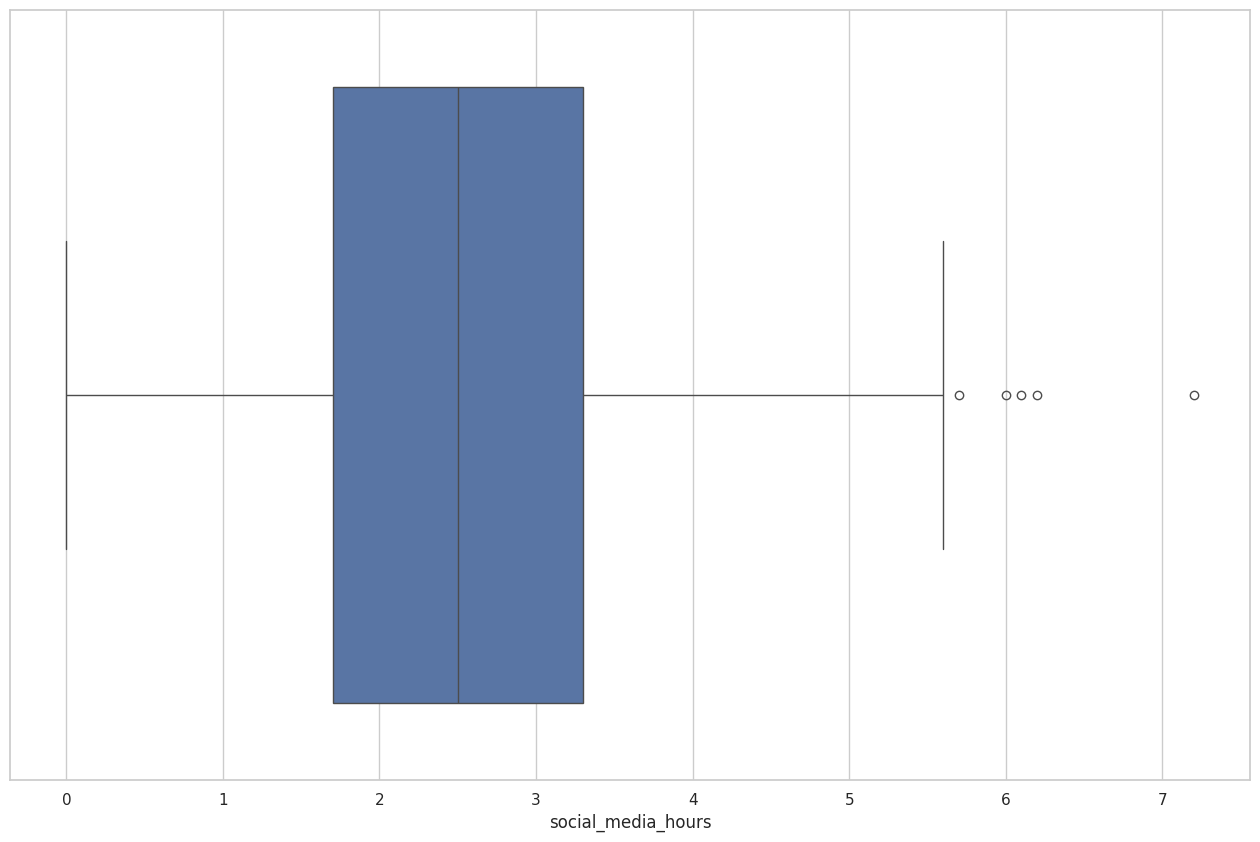

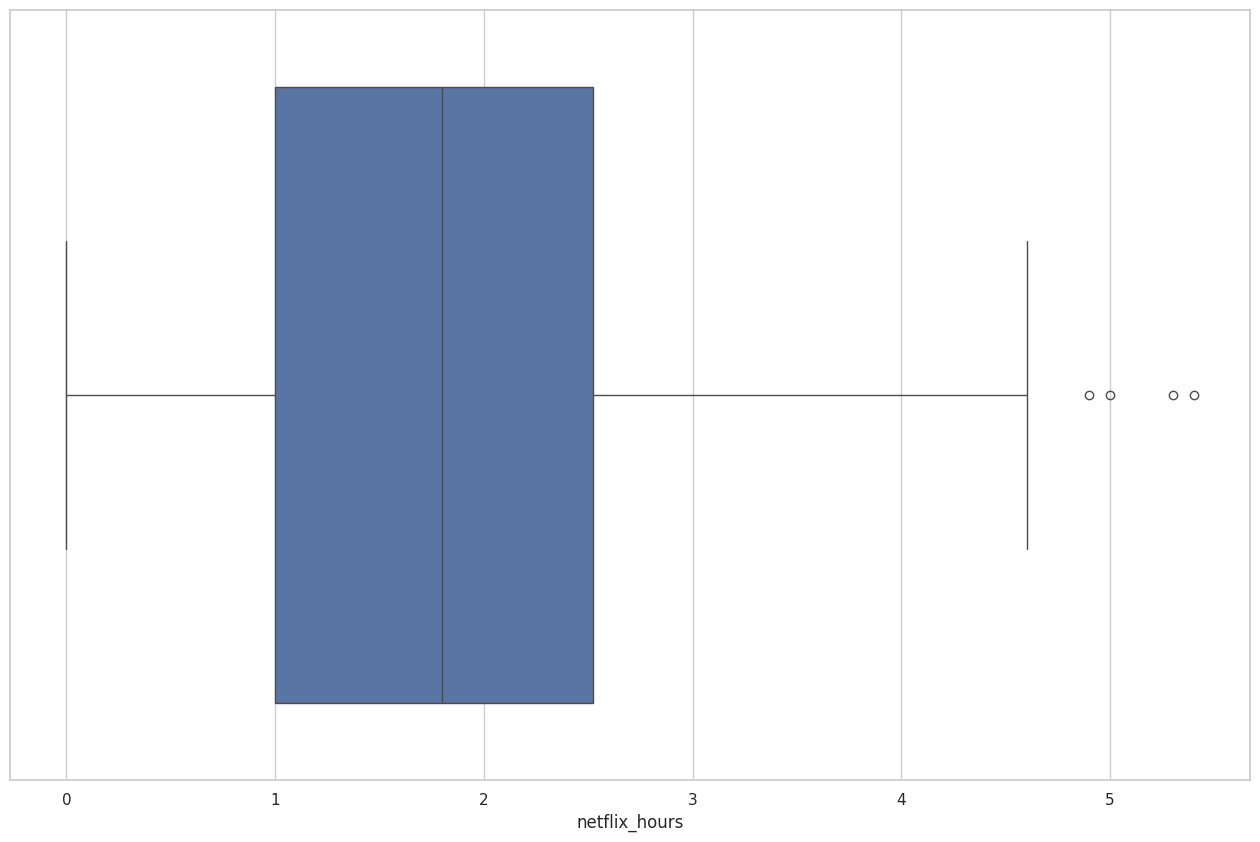

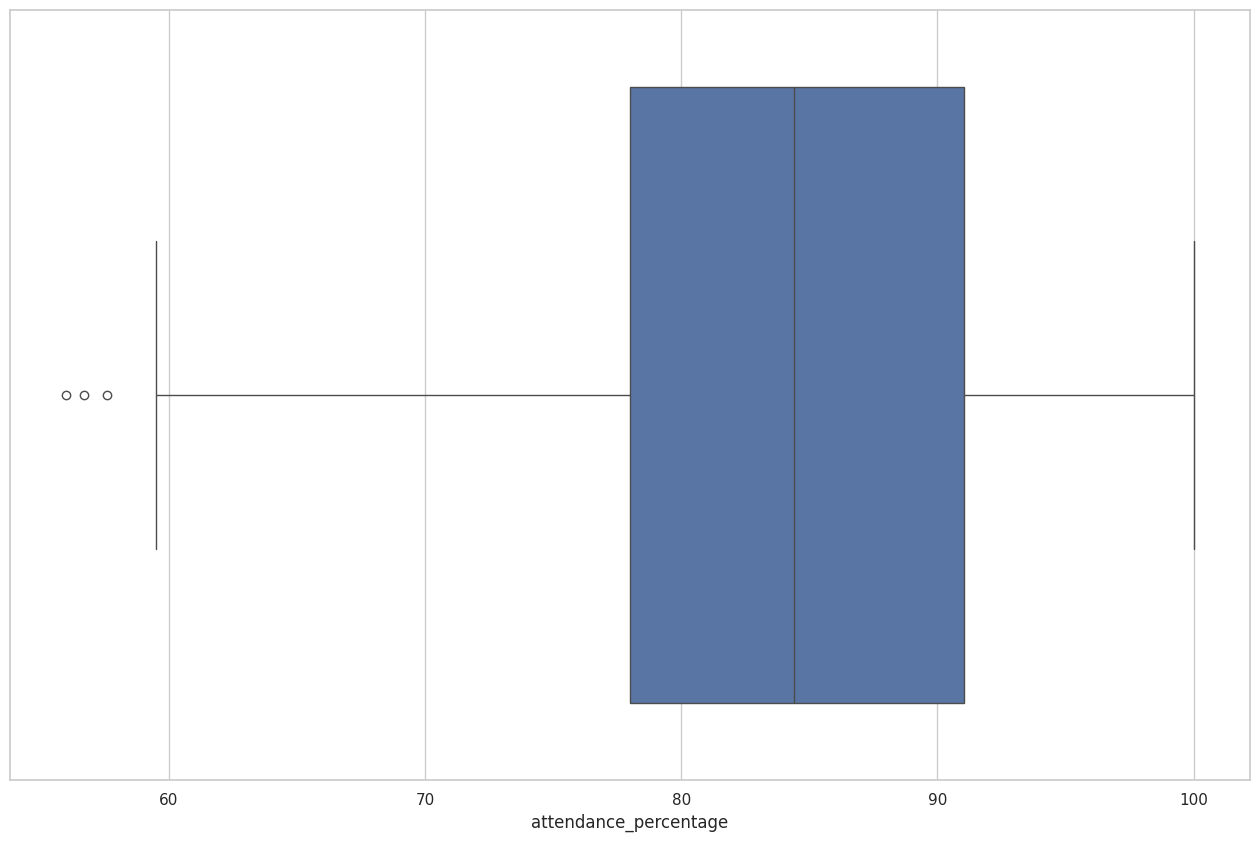

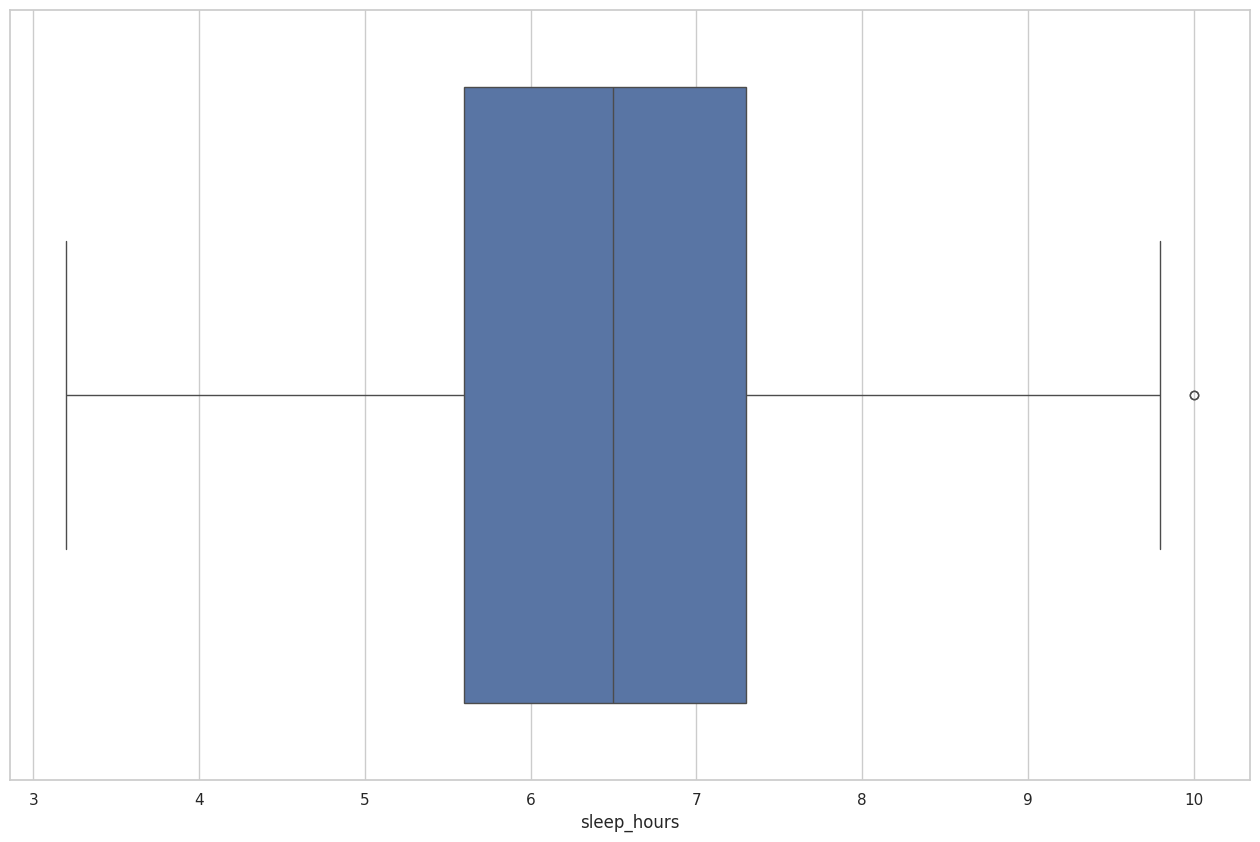

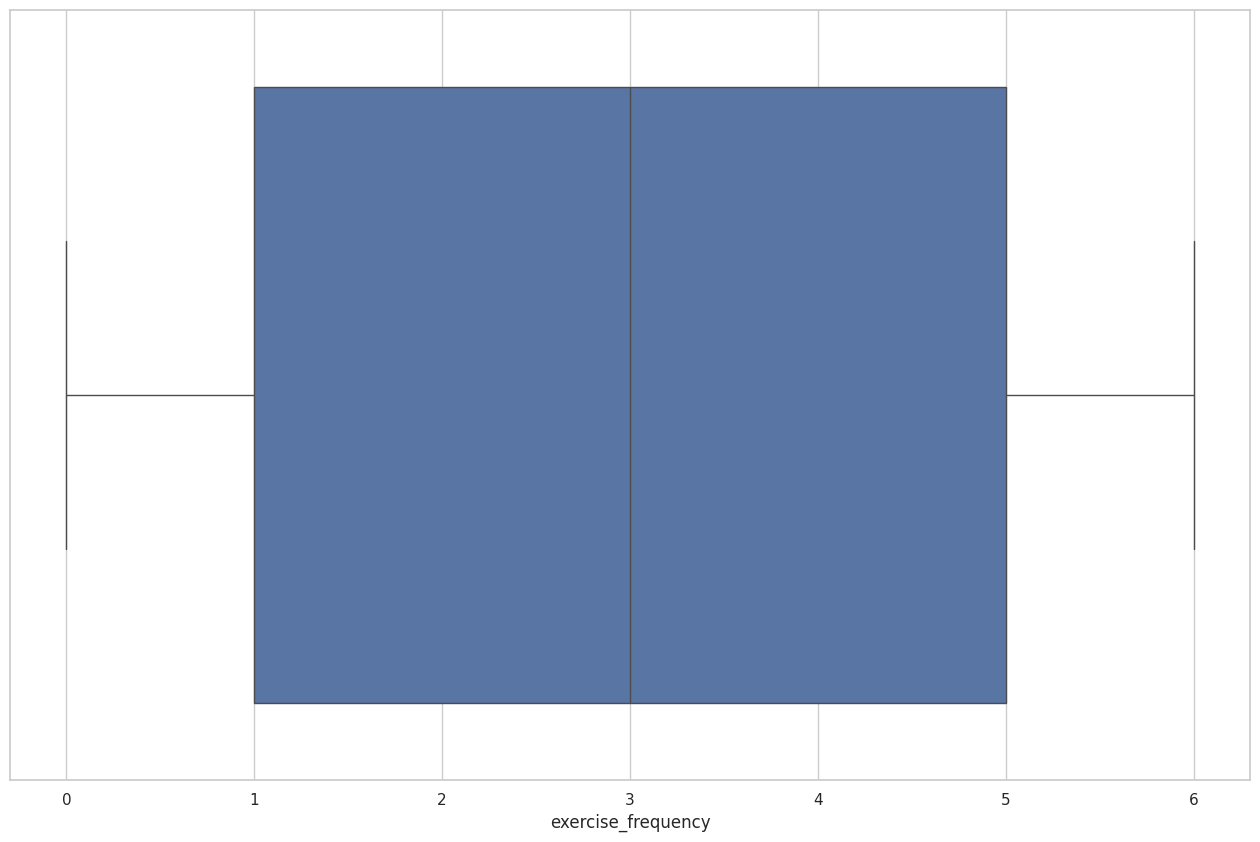

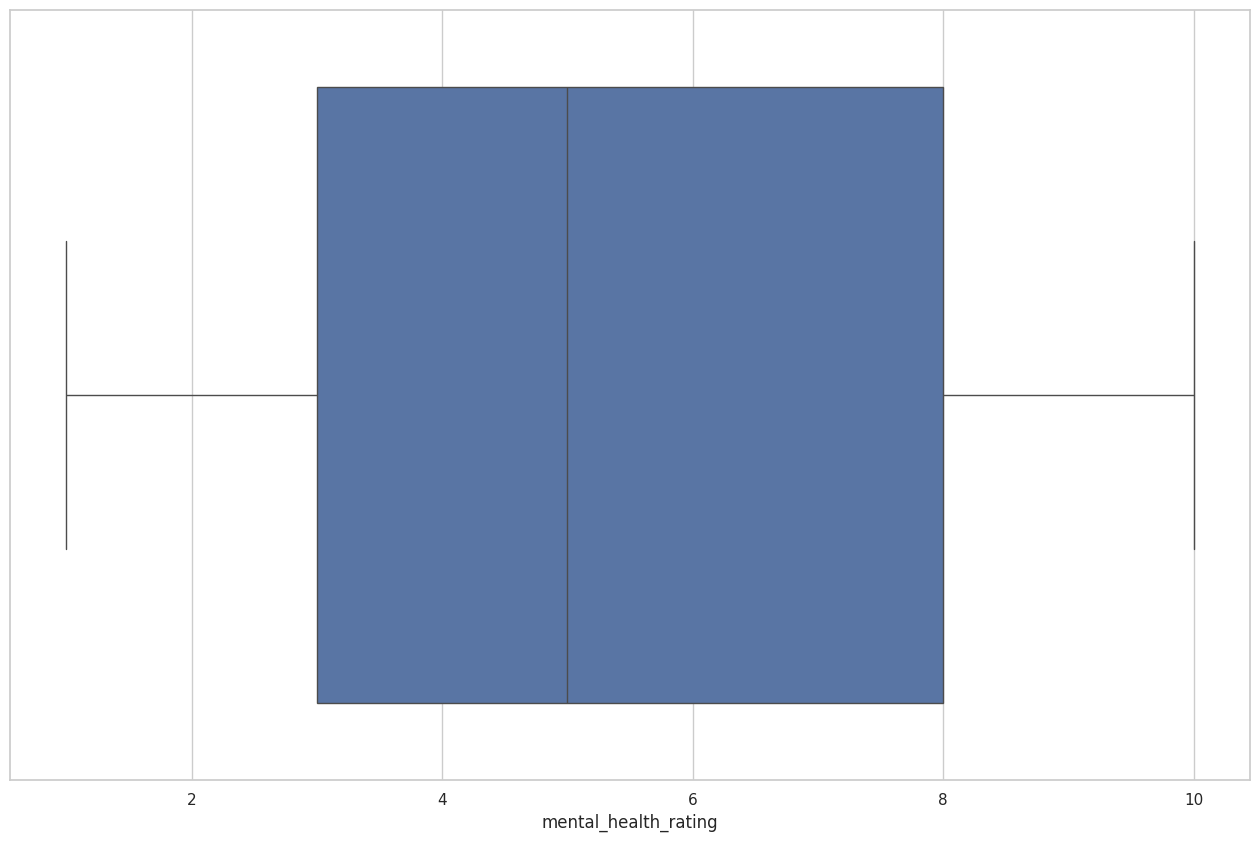

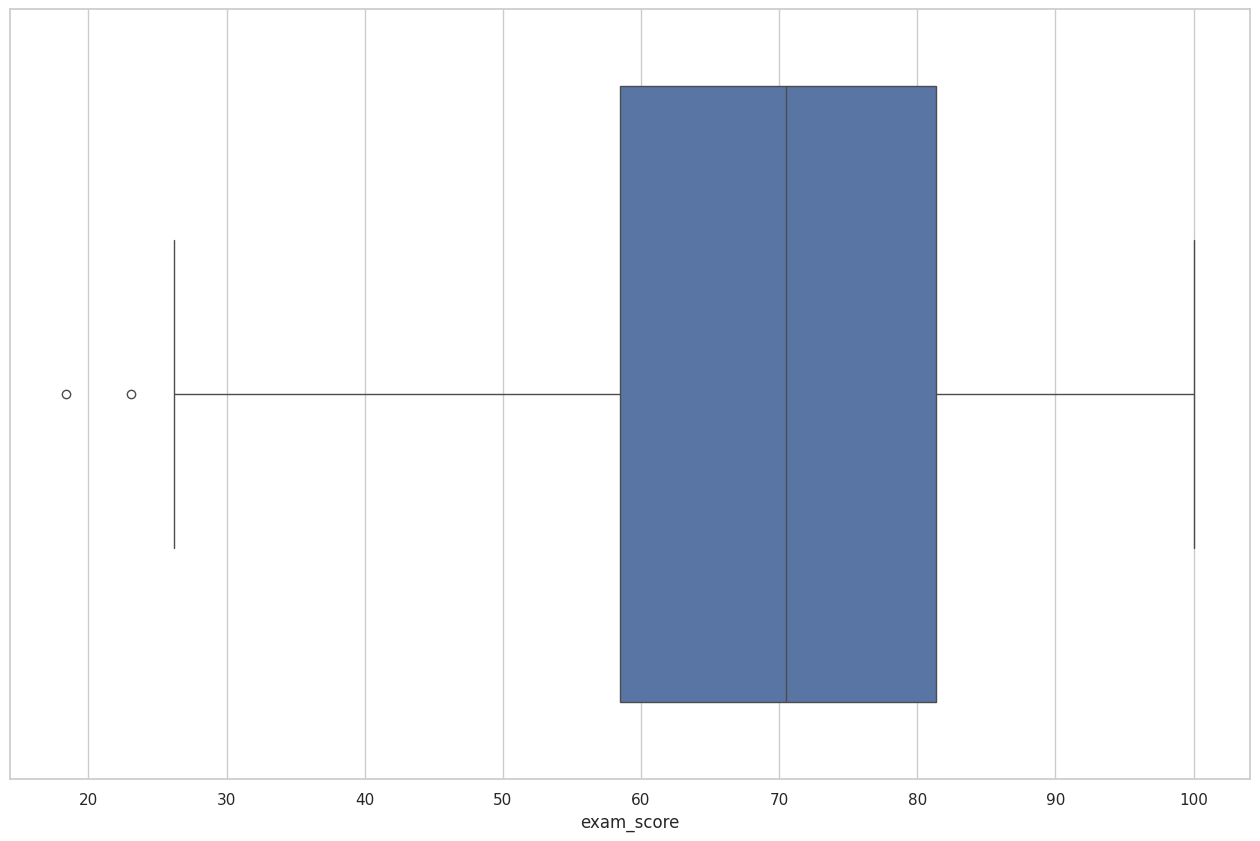

In [129]:
for col in df.select_dtypes(include='number').columns:
  plt.figure(figsize=(16,10))
  sns.boxplot(x=df[col])
  plt.show()

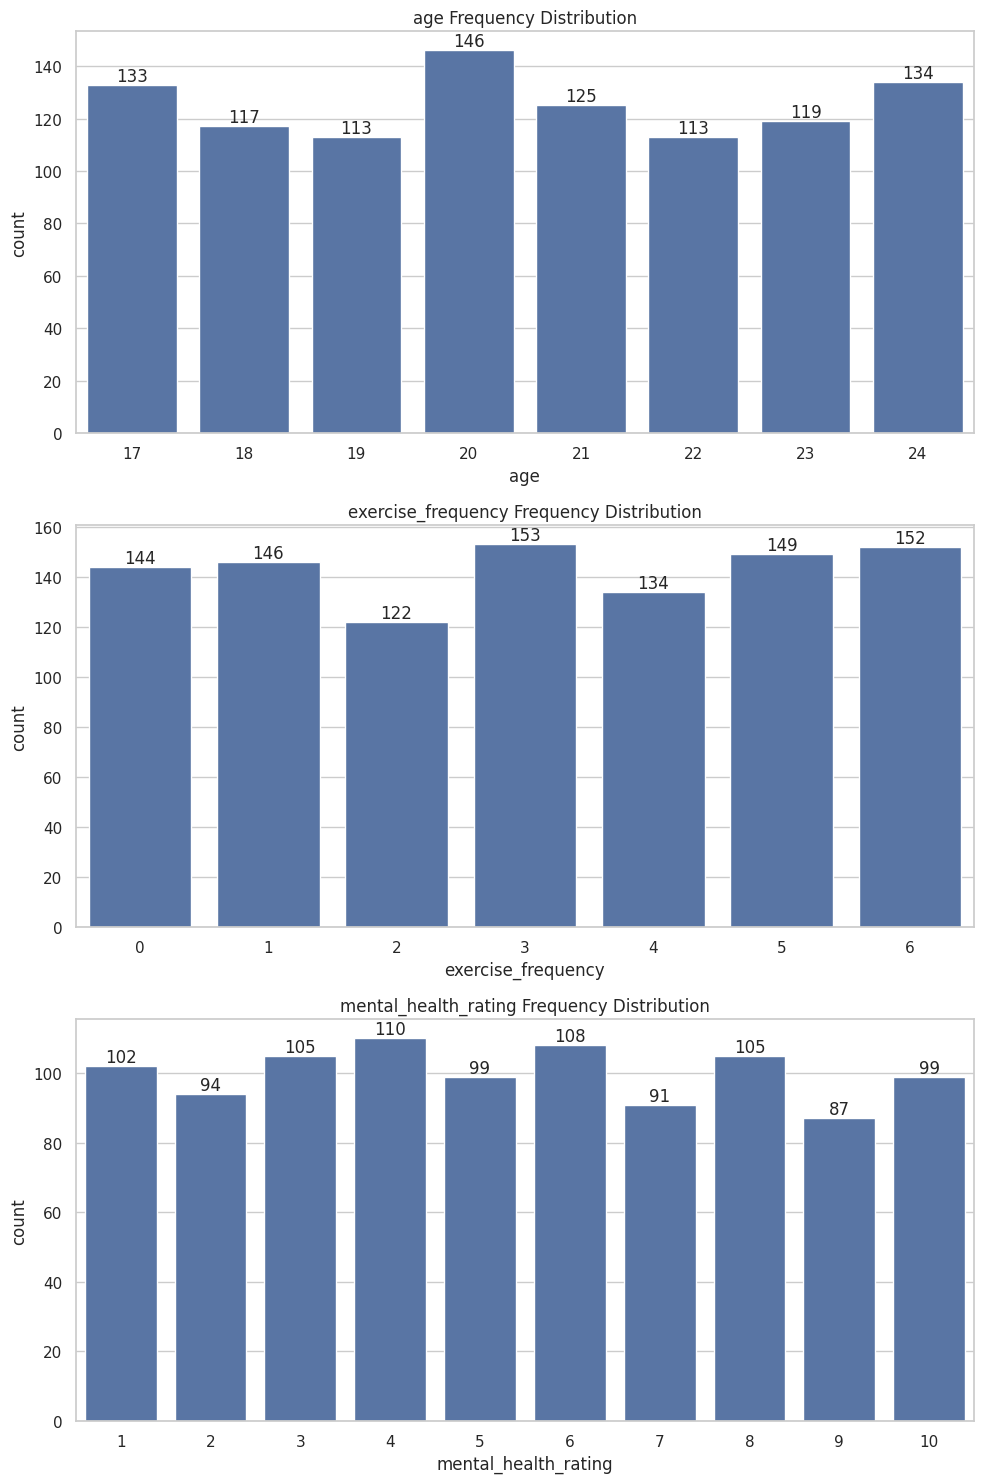

In [130]:
#Bar chart untuk data diskrit

diskrit_feature = df.select_dtypes(include = int)

n = len(diskrit_feature.columns)
fig, axes = plt.subplots(n, 1, figsize=(10, 5*n))

for i, var in enumerate(diskrit_feature.columns):
    ax = sns.countplot(x=var, data=df, ax=axes[i])
    axes[i].set_title(f"{var} Frequency Distribution")

    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width()/2., p.get_height()),
                    ha = 'center', va = 'bottom')


plt.tight_layout()
plt.show()

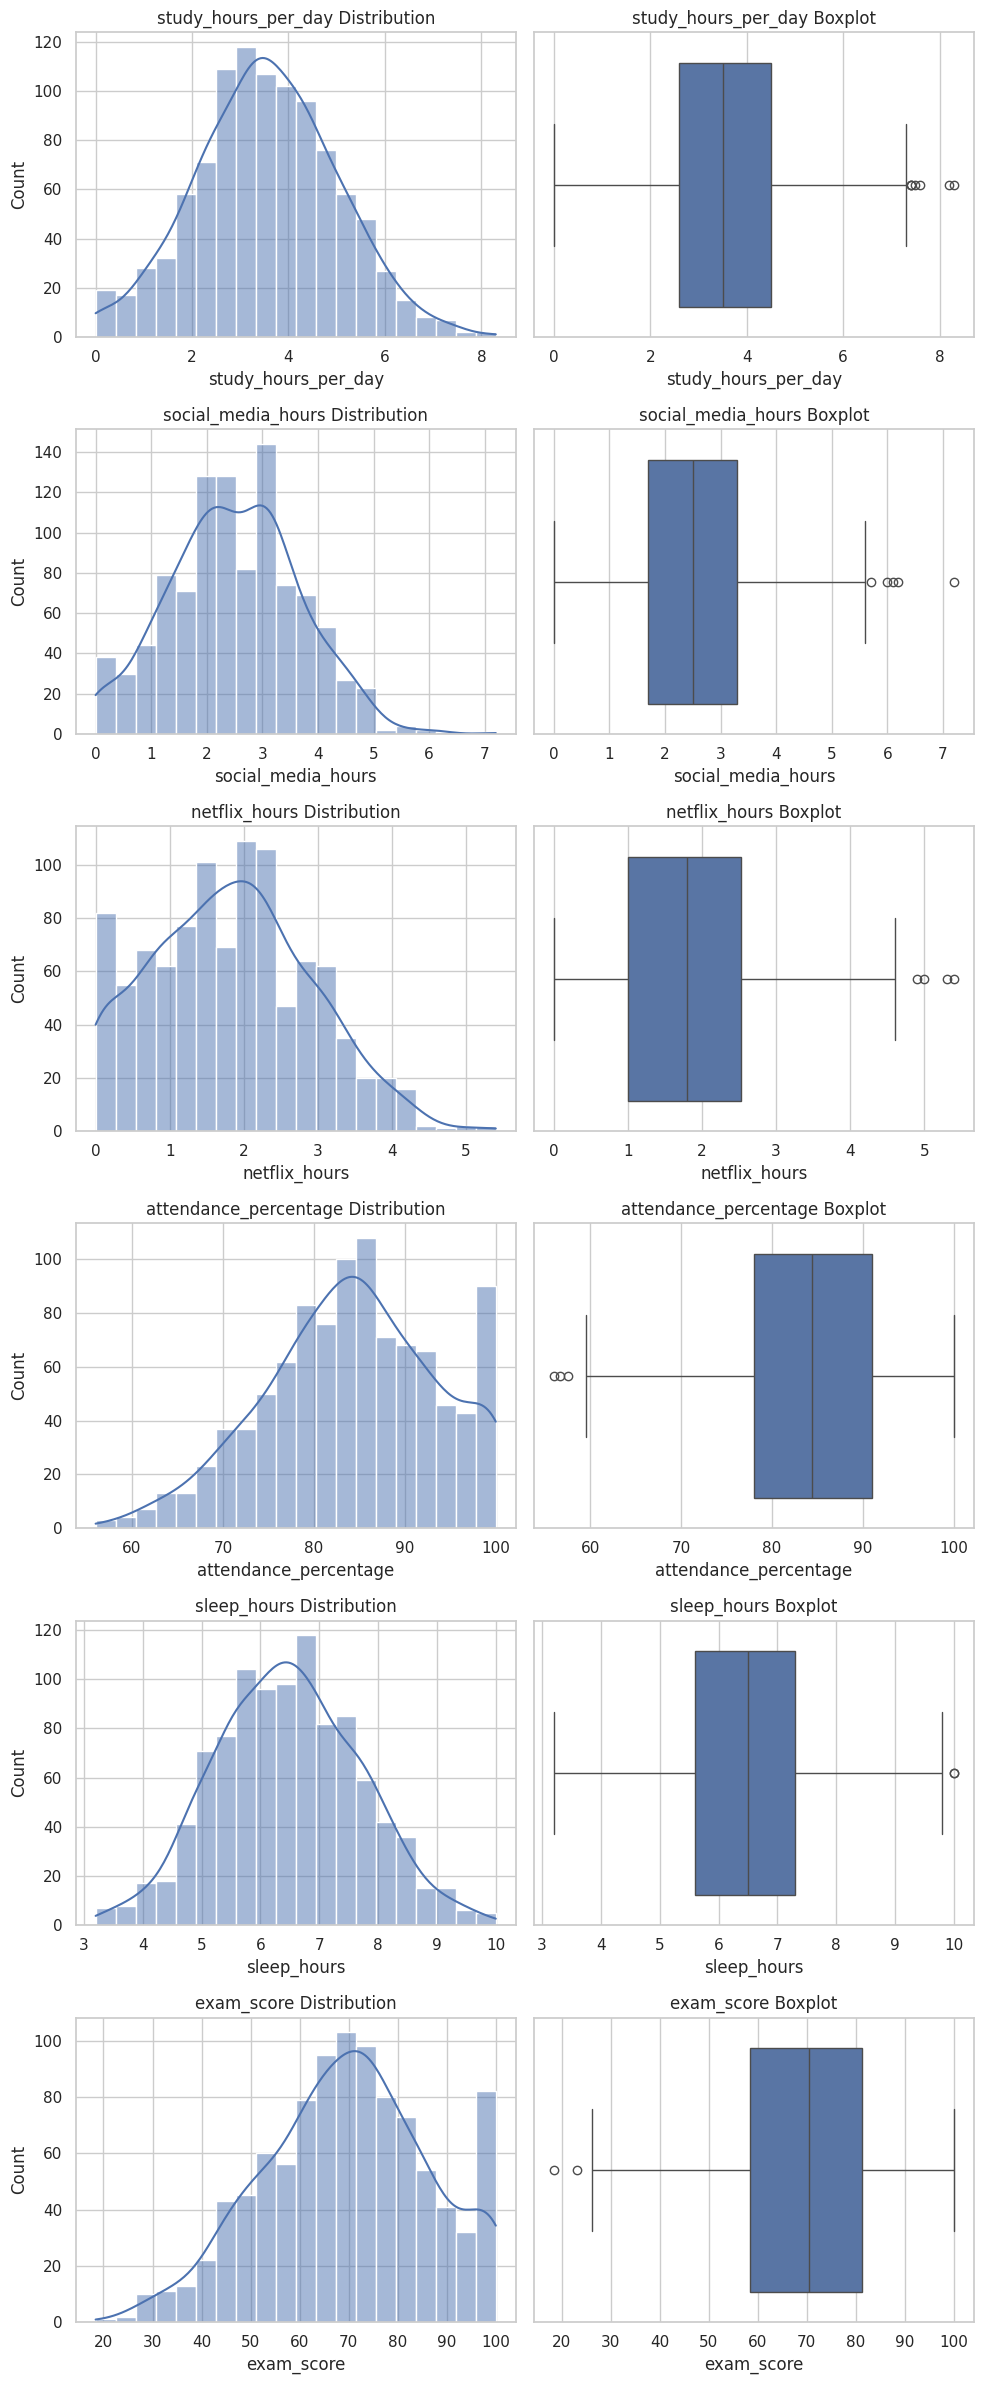

In [131]:
#histogram dan boxplot untuk data kontinu
data_kontinu = df.select_dtypes(include='float').columns

fig, axes = plt.subplots(
    nrows=len(data_kontinu),
    ncols=2,
    figsize=(10, len(data_kontinu)*4)
)

for i, col in enumerate(data_kontinu):
    # Histogram
    sns.histplot(data=df, x=col, bins=20, kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f'{col} Distribution')

    # Boxplot
    sns.boxplot(data=df, x=col, ax=axes[i, 1])
    axes[i, 1].set_title(f'{col} Boxplot')

plt.tight_layout()
plt.show()

Dari histogram kolom **study_per_hour** dapat dilihat bahwa kolom tersebut berdistribusi normal, sama seperti kolom **sleep_hours_distribution**. Sedangkan kolom lain distribusinya cenderung skew. Dari boxplot setiap kolom kontinu di atas, dapat terlihat tiap kolom memiliki outlier.

In [132]:
df_kategorik = df.select_dtypes('object').columns

print(f'Total unique values di setiap data kategorik:\n{"="*39}')
for feature in df_kategorik:
    print(f"{feature}: {df[feature].nunique()}")

Total unique values di setiap data kategorik:
student_id: 1000
gender: 3
part_time_job: 2
diet_quality: 3
parental_education_level: 3
internet_quality: 3
extracurricular_participation: 2


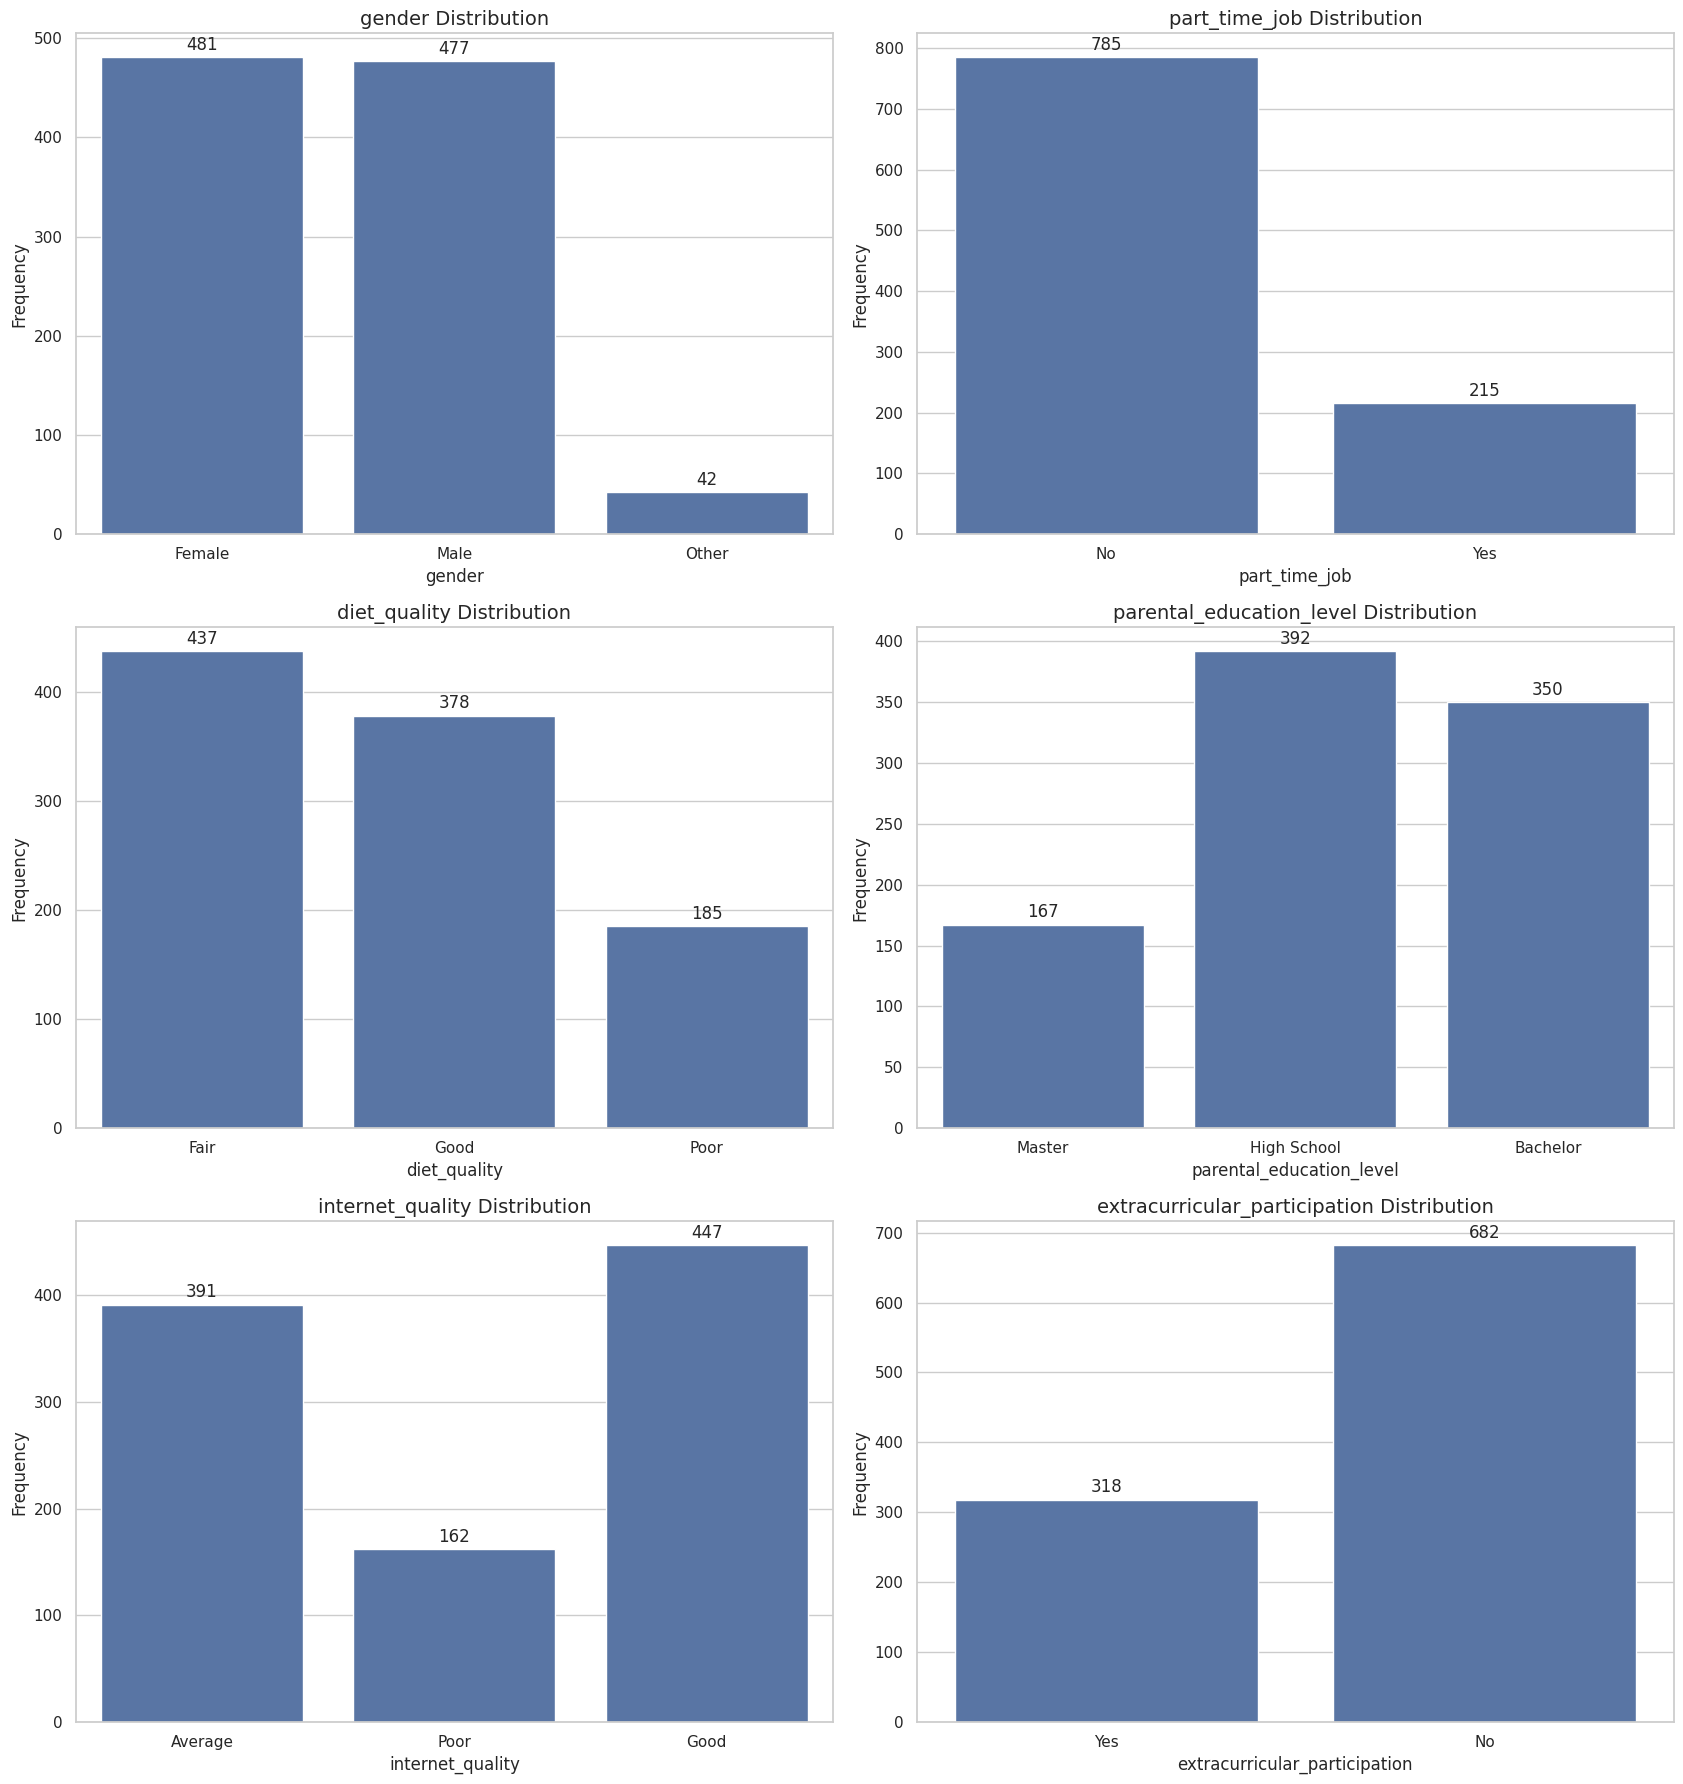

In [133]:
#karena student_id berisi data unik, maka tidak perlu dibuat visualisasinya
df_kategorik = ["gender", "part_time_job", "diet_quality", "parental_education_level", "internet_quality", "extracurricular_participation"]

fig, axes= plt.subplots(3, 2, figsize=(17,18))
axes = axes.flatten()

for ax, feature in enumerate(df_kategorik):
    sns.countplot(x= feature, data= df, ax= axes[ax])
    axes[ax].set_title(f'{feature} Distribution', fontsize = 14)
    axes[ax].set_xlabel(feature, fontsize = 12)
    axes[ax].set_ylabel('Frequency', fontsize= 12)

    for b in axes[ax].patches:
        axes[ax].annotate(f'{int(b.get_height())}',
                          (b.get_x() + b.get_width()/2., b.get_height()),
                          ha = 'center', va = 'center',
                          xytext = (0,9),
                          textcoords = "offset points")

plt.tight_layout()
plt.show()

Perbedaan frequensi paling beda terlihat di kolom **"part_time_job"** dimana mahasiswa kebanyakan tidak melakukan kerja paruh waktu

## Bivariate Analysis

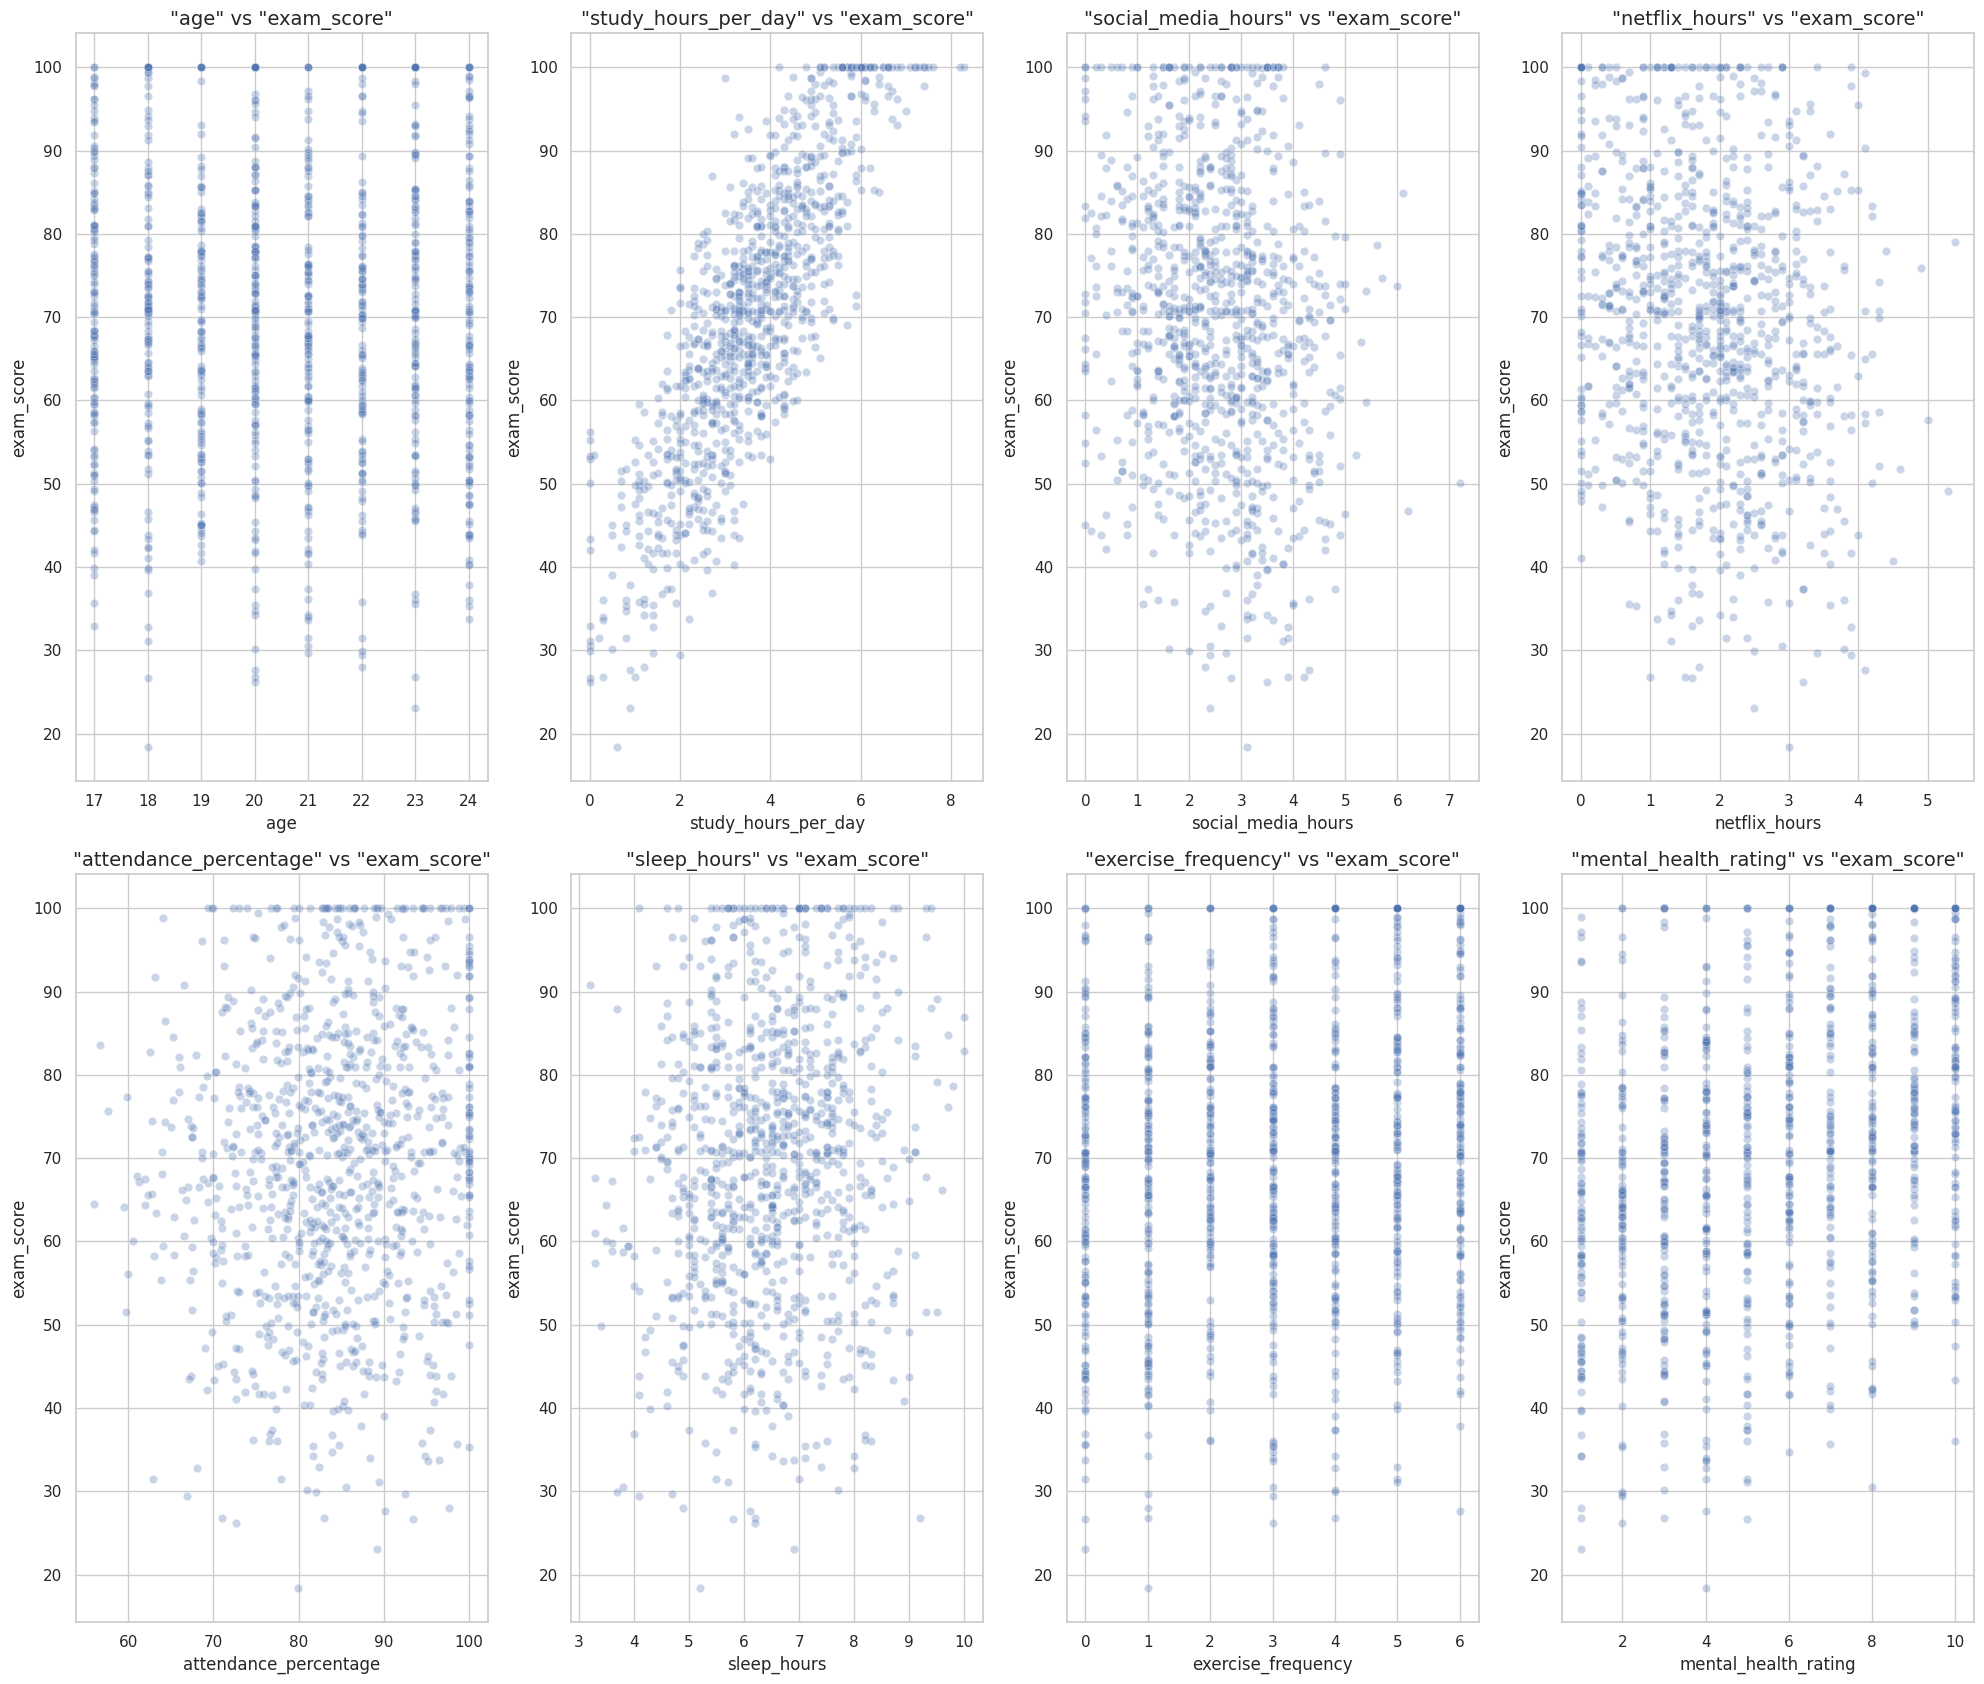

In [134]:
var_numerik = df.drop('exam_score', axis= 1).select_dtypes(include= ["int64", "float64"]).columns

fig, axes = plt.subplots(2, 4, figsize = (20,17))
axes = axes.flatten()

for ax, variabel in enumerate(var_numerik):
    sns.scatterplot(data = df, x= variabel, y= 'exam_score', ax= axes[ax], alpha=0.3)
    axes[ax].set_title(f'"{variabel}" vs "exam_score"', fontsize = 14)
    axes[ax].set_xlabel(variabel, fontsize = 12)
    axes[ax].set_ylabel("exam_score", fontsize = 12)

plt.tight_layout()
plt.show()

Terlihat pola scatterplot feature "study_hours_per_day" dan "exam_score" terlihat hubungannya positif kuat. hal ini bisa dilihat dari heatmap korelasi di bawah

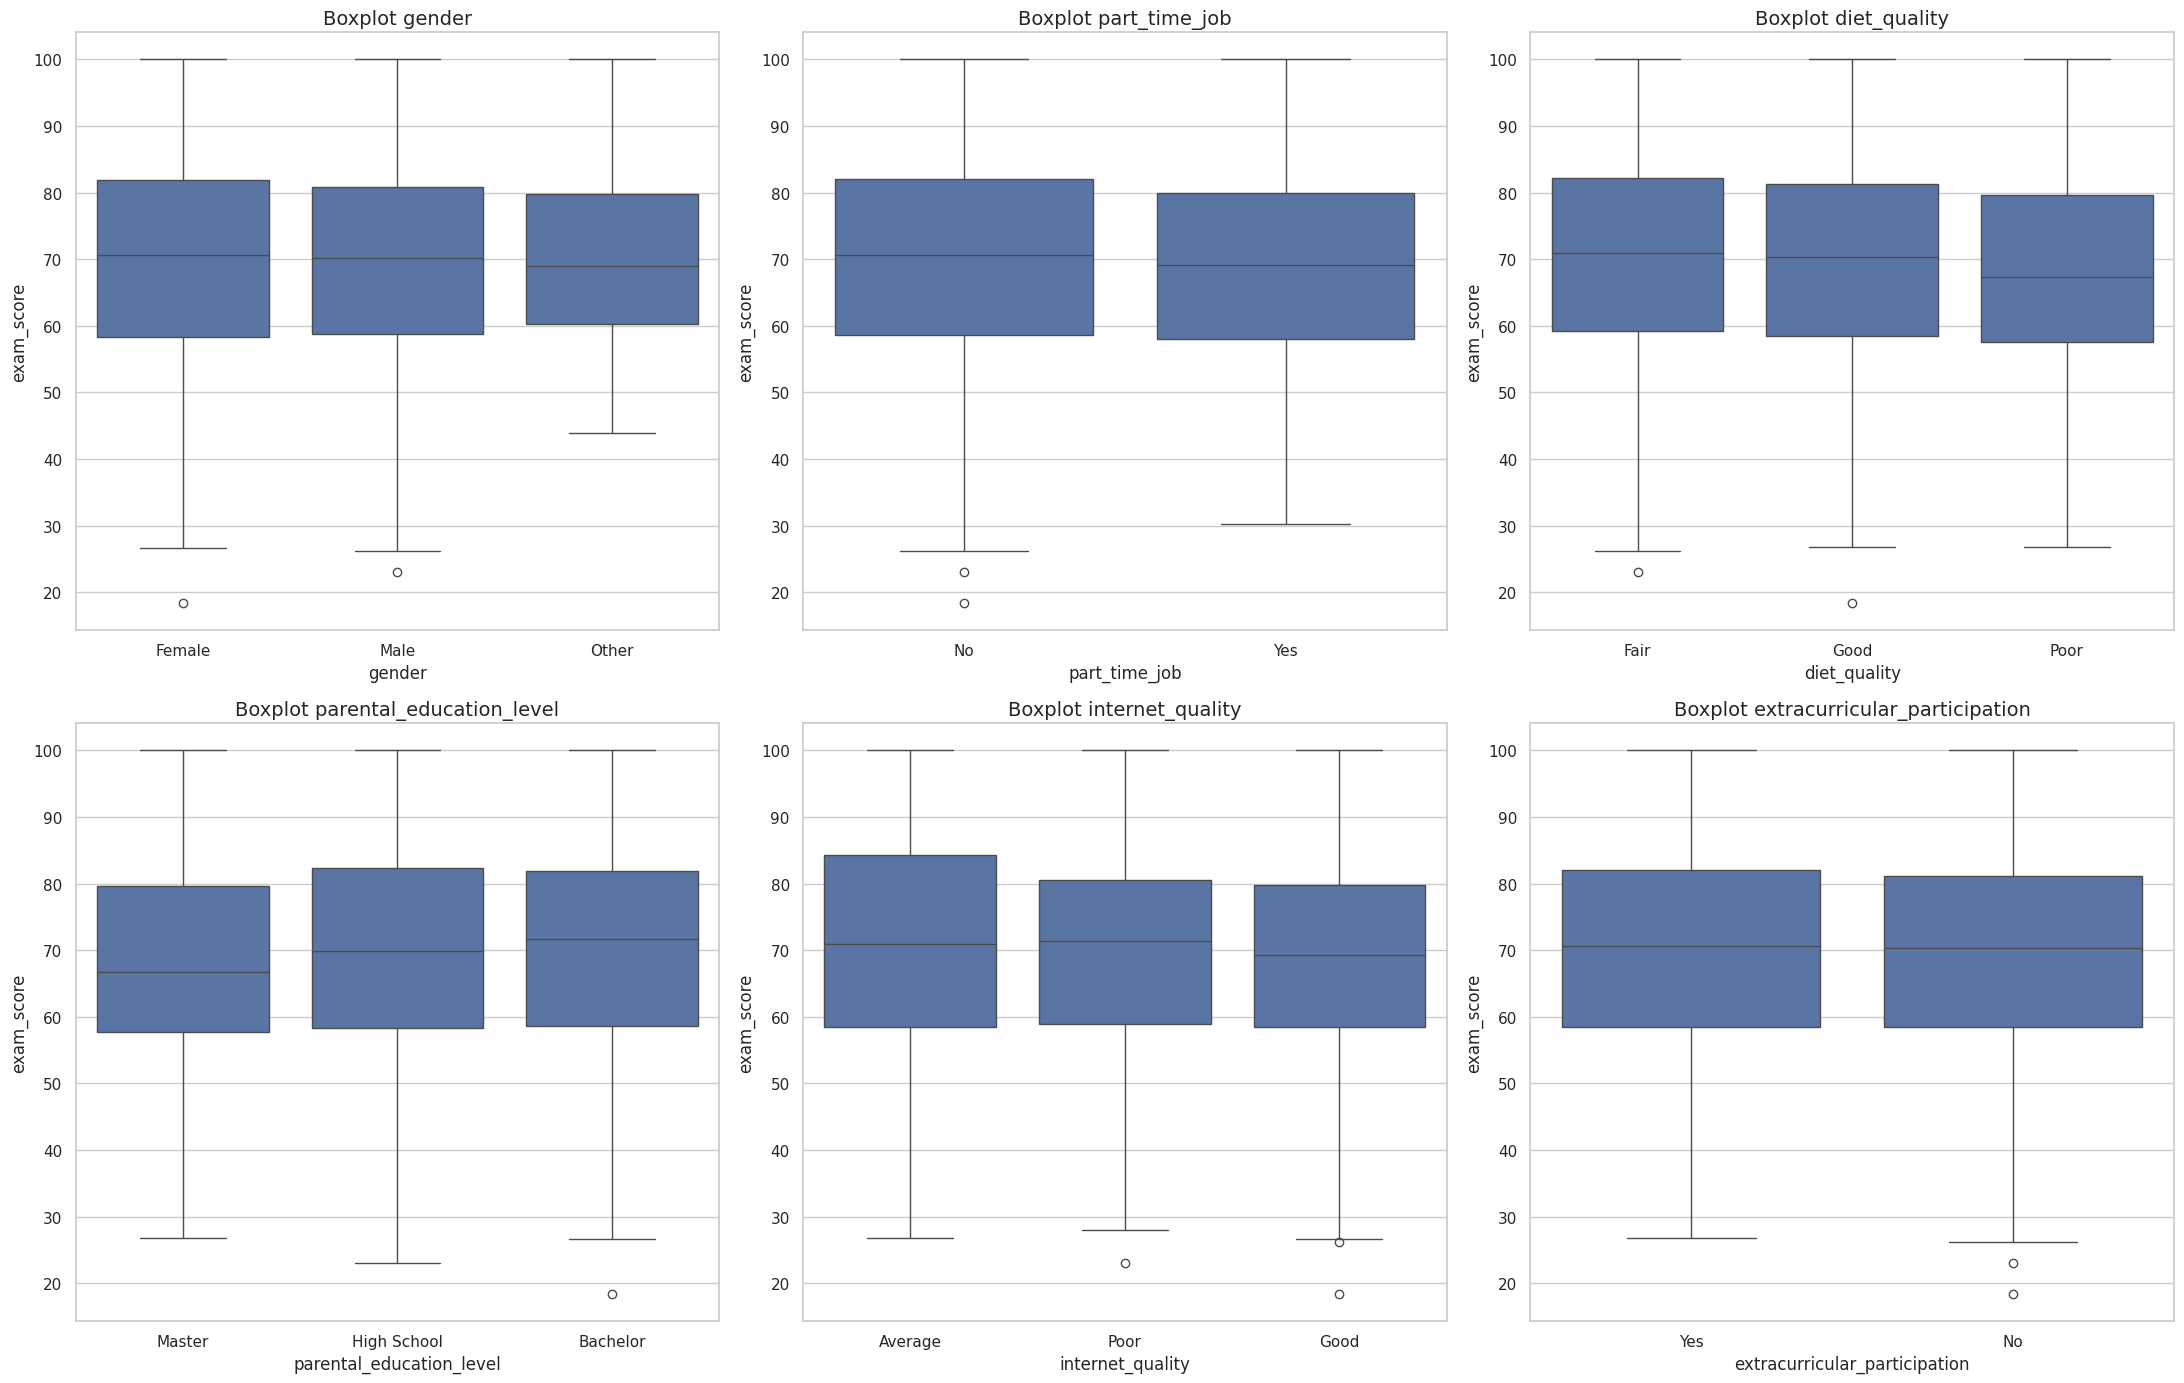

In [135]:
#boxplot untuk beberapa data kategorik vs variabel exam_score

#boxplot umtuk beberapa data kategorik dengan variabel exam_score

df_kategorik = ["gender", "part_time_job", "diet_quality", "parental_education_level", "internet_quality", "extracurricular_participation"]

fig, axes = plt.subplots(2, 3, figsize= (22, 14))
axes = axes.flatten()

for ax, variabel in enumerate(df_kategorik):
    sns.boxplot(data = df, x= variabel, y= "exam_score", ax = axes[ax])
    axes[ax].set_title(f'Boxplot {variabel}', fontsize= 14)
    axes[ax].set_xlabel(variabel, fontsize= 12)
    axes[ax].set_ylabel("exam_score", fontsize= 12)

plt.tight_layout()
plt.show()

## Multivariate Analysis

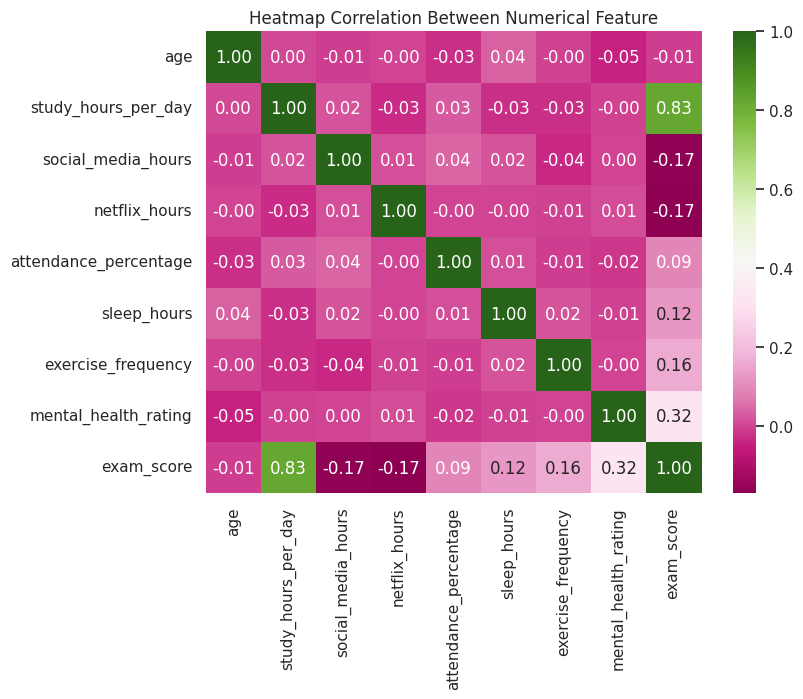

In [136]:
#heatmap
numerical_feature = df.select_dtypes(include = ['int64', 'float64'])

correlation_matrix = numerical_feature.corr()
plt.figure(figsize= (8,6))
sns.heatmap(data= correlation_matrix, annot= True, cmap='PiYG', fmt=".2f")

plt.title('Heatmap Correlation Between Numerical Feature')
plt.show()

Korelasi paling tinggi ada di kolom **exam_score** dengan **study_hours_per_day** sebesar 0.83

# **Identifikasi Mean-Median-Modus, Normalisasi Data**

In [137]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Membaca data
df = pd.read_csv('student_habits_performance.csv')
df_clean = df.dropna().drop_duplicates()

# Menyeleksi kolom khusus angka
numeric_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns

# --- 1. MENGHITUNG MEAN, MEDIAN, MODUS ---
mean_vals = df_clean[numeric_cols].mean()
median_vals = df_clean[numeric_cols].median()
mode_vals = df_clean[numeric_cols].mode().iloc[0]

stats_df = pd.DataFrame({
    'Mean': mean_vals, 'Median': median_vals, 'Modus': mode_vals
})
print(stats_df)

# --- 2. NORMALISASI DATA (SKALA 0 SAMPAI 1) ---
scaler = MinMaxScaler()
df_normalized = df_clean.copy()
# Transformasi semua kolom numerik dengan MinMaxScaler
df_normalized[numeric_cols] = scaler.fit_transform(df_normalized[numeric_cols])

# Ekspor Data hasil normalisasi
df_normalized.to_csv('normalized_student_data.csv', index=False)

                            Mean  Median  Modus
age                    20.475248    20.0   20.0
study_hours_per_day     3.538724     3.5    3.2
social_media_hours      2.504620     2.5    2.2
netflix_hours           1.830363     1.8    0.0
attendance_percentage  83.880308    84.2  100.0
sleep_hours             6.474037     6.5    6.5
exercise_frequency      3.051705     3.0    6.0
mental_health_rating    5.466447     5.0    4.0
exam_score             69.558196    70.4  100.0


# **DATA CLEANING**

Cek Outlier

In [138]:
for col in df.select_dtypes(include='number').columns:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3-q1

  batas_bawah = q1 - 1.5 * iqr
  batas_atas = q3 + 1.5 * iqr

  outliers = df[(df[col] < batas_bawah) | (df[col] > batas_atas)]
  print(f"{col}: {len(outliers)} outliers")

age: 0 outliers
study_hours_per_day: 7 outliers
social_media_hours: 5 outliers
netflix_hours: 4 outliers
attendance_percentage: 3 outliers
sleep_hours: 2 outliers
exercise_frequency: 0 outliers
mental_health_rating: 0 outliers
exam_score: 2 outliers


Terdapat Outlier pada bbrp kolom

Handling Outlier

In [139]:
df_copy = df.copy()
mask = np.ones(len(df_copy),dtype=bool)
for col in df_copy.select_dtypes(include='number').columns:
  q1 = df_copy[col].quantile(0.25)
  q3 = df_copy[col].quantile(0.75)
  iqr = q3-q1

  batas_bawah = q1 - 1.5 * iqr
  batas_atas = q3 + 1.5 * iqr
  mask &= (df_copy[col] >= batas_bawah) & (df_copy[col] <= batas_atas)

df_clean = df_copy[mask]


Cek Outlier (stlh handling)

In [140]:
for col in df_clean.select_dtypes(include='number').columns:
  q1 = df_clean[col].quantile(0.25)
  q3 = df_clean[col].quantile(0.75)
  iqr = q3-q1

  batas_bawah = q1 - 1.5 * iqr
  batas_atas = q3 + 1.5 * iqr

  outliers = df[(df_clean[col] < batas_bawah) | (df[col] > batas_atas)]
  print(f"{col}: {len(outliers)} outliers")


age: 0 outliers
study_hours_per_day: 0 outliers
social_media_hours: 0 outliers
netflix_hours: 0 outliers
attendance_percentage: 0 outliers
sleep_hours: 0 outliers
exercise_frequency: 0 outliers
mental_health_rating: 0 outliers
exam_score: 0 outliers


Handling Missing Value

In [141]:
df_clean['parental_education_level'] = df_clean['parental_education_level'].fillna("Unknown")
df_clean['parental_education_level'].isnull().sum()

/tmp/ipykernel_24459/4215188579.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['parental_education_level'] = df_clean['parental_education_level'].fillna("Unknown")


np.int64(0)

In [142]:
df_clean.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


Handling Duplicate Row

In [143]:
df_clean = df_clean.drop_duplicates()

In [144]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 977 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     977 non-null    object 
 1   age                            977 non-null    int64  
 2   gender                         977 non-null    object 
 3   study_hours_per_day            977 non-null    float64
 4   social_media_hours             977 non-null    float64
 5   netflix_hours                  977 non-null    float64
 6   part_time_job                  977 non-null    object 
 7   attendance_percentage          977 non-null    float64
 8   sleep_hours                    977 non-null    float64
 9   diet_quality                   977 non-null    object 
 10  exercise_frequency             977 non-null    int64  
 11  parental_education_level       977 non-null    object 
 12  internet_quality               977 non-null    object 


# **FEATURE ENGINEERING**

One-Hot Encoding

In [145]:
df_clean = pd.get_dummies(df_clean, columns = ['gender', 'part_time_job', 'extracurricular_participation'], drop_first=True)

df_clean.head()

,student_id,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,exam_score,gender_Male,gender_Other,part_time_job_Yes,extracurricular_participation_Yes
0,S1000,23,0.0,1.2,1.1,85.0,8.0,Fair,6,Master,Average,8,56.2,False,False,False,True
1,S1001,20,6.9,2.8,2.3,97.3,4.6,Good,6,High School,Average,8,100.0,False,False,False,False
2,S1002,21,1.4,3.1,1.3,94.8,8.0,Poor,1,High School,Poor,1,34.3,True,False,False,False
3,S1003,23,1.0,3.9,1.0,71.0,9.2,Poor,4,Master,Good,1,26.8,False,False,False,True
4,S1004,19,5.0,4.4,0.5,90.9,4.9,Fair,3,Master,Good,1,66.4,False,False,False,False


Diskritisasi Data (study_hours_per_day)

In [146]:
# Diskritisasi
df_clean['study_category'] = pd.cut(
    df_clean['study_hours_per_day'],
    bins=[0, 3, 6, 10],
    labels=['Low', 'Medium', 'High']
)

# Encoding hasil diskritisasi
df_clean = pd.get_dummies(df_clean, columns=['study_category'], drop_first=True)

df_clean.head()

,student_id,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,exam_score,gender_Male,gender_Other,part_time_job_Yes,extracurricular_participation_Yes,study_category_Medium,study_category_High
0,S1000,23,0.0,1.2,1.1,85.0,8.0,Fair,6,Master,Average,8,56.2,False,False,False,True,False,False
1,S1001,20,6.9,2.8,2.3,97.3,4.6,Good,6,High School,Average,8,100.0,False,False,False,False,False,True
2,S1002,21,1.4,3.1,1.3,94.8,8.0,Poor,1,High School,Poor,1,34.3,True,False,False,False,False,False
3,S1003,23,1.0,3.9,1.0,71.0,9.2,Poor,4,Master,Good,1,26.8,False,False,False,True,False,False
4,S1004,19,5.0,4.4,0.5,90.9,4.9,Fair,3,Master,Good,1,66.4,False,False,False,False,True,False


Train-Test-Split & Transformasi Data (Feature Scaling)

In [147]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df_clean.drop(columns=['exam_score'])
y = df_clean['exam_score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

sc = StandardScaler()
X_train[['study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours']] = sc.fit_transform(
    X_train[['study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours']]
)
X_test[['study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours']] = sc.transform(
    X_test[['study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours']]
)

X_train[['study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours']].head()

,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours
693,0.973084,0.260649,-1.138465,0.494662,0.443241
755,-0.564910,1.941561,-0.095095,-1.777558,-0.635174
33,0.343905,-1.420262,-0.664206,1.652208,-0.552219
31,-1.403815,0.526057,0.758572,1.298514,1.272792
745,0.483722,0.791464,-0.379650,-0.266317,0.277331


In [148]:
X_train.head()

,student_id,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,gender_Male,gender_Other,part_time_job_Yes,extracurricular_participation_Yes,study_category_Medium,study_category_High
693,S1693,20,0.973084,0.260649,-1.138465,0.494662,0.443241,Fair,5,High School,Average,6,False,False,False,False,True,False
755,S1755,22,-0.564910,1.941561,-0.095095,-1.777558,-0.635174,Poor,2,Master,Good,9,True,False,True,False,False,False
33,S1033,18,0.343905,-1.420262,-0.664206,1.652208,-0.552219,Poor,2,Unknown,Average,5,False,False,False,False,True,False
31,S1031,17,-1.403815,0.526057,0.758572,1.298514,1.272792,Fair,4,Bachelor,Average,3,False,True,True,True,False,False
745,S1745,18,0.483722,0.791464,-0.379650,-0.266317,0.277331,Good,2,Master,Average,4,False,False,False,False,True,False


# **MODEL TRAINING**

import library

In [149]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [150]:
# Preprocessing Kategorikal (Safeguard)
X_train_enc = pd.get_dummies(X_train, drop_first=True)
X_test_enc = pd.get_dummies(X_test, drop_first=True)
X_train_enc, X_test_enc = X_train_enc.align(X_test_enc, join='left', axis=1, fill_value=0)

train model

In [151]:
# Inisialisasi Model
models_to_train = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42, objective='reg:squarederror')
}

trained_models = {}

for name, model in models_to_train.items():
    model.fit(X_train_enc, y_train)

    # Simpan model yang sudah pintar ke dalam dictionary
    trained_models[name] = model

#  **MODEL EVALUATION**

In [152]:
results = []

for name, trained_model in trained_models.items():

    # Lakukan Prediksi
    y_pred = trained_model.predict(X_test_enc)

    # Hitung Rapor (Metrik)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    # Catat Hasil
    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })
    print(f"📊 Evaluasi selesai: {name}")

# Tampilkan Papan Skor
df_results = pd.DataFrame(results).sort_values(by="R2 Score", ascending=False).reset_index(drop=True)
print("\n=== HASIL AKHIR EVALUASI 5 MODEL ===")
display(df_results)

📊 Evaluasi selesai: Linear Regression
📊 Evaluasi selesai: Ridge Regression
📊 Evaluasi selesai: Random Forest
📊 Evaluasi selesai: Gradient Boosting
📊 Evaluasi selesai: XGBoost

=== HASIL AKHIR EVALUASI 5 MODEL ===


,Model,MAE,RMSE,R2 Score
0,Ridge Regression,4.418222,5.475044,0.894398
1,Linear Regression,4.463846,5.531896,0.892194
2,Gradient Boosting,4.869870,6.110008,0.868484
3,XGBoost,5.081155,6.453762,0.853269
4,Random Forest,5.286628,6.603309,0.846390


visualisasi hasil evaluasi

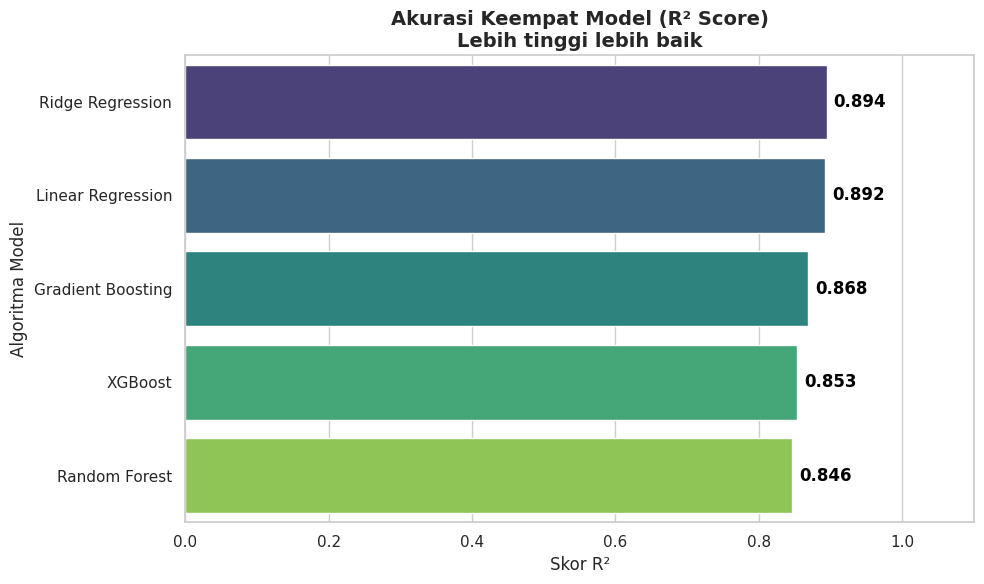

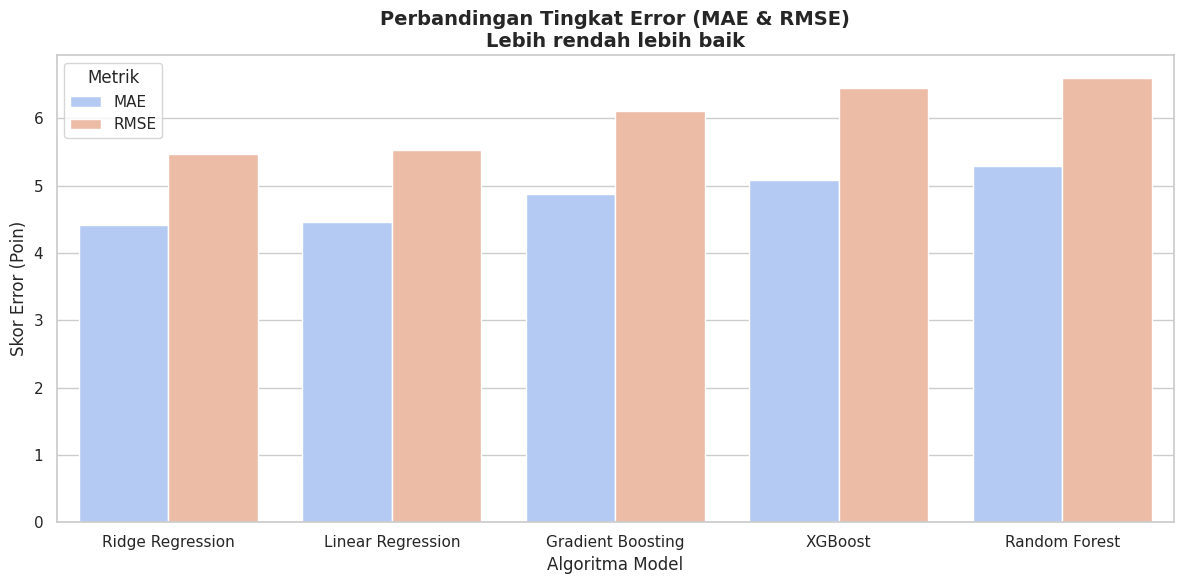

In [153]:
sns.set_theme(style="whitegrid")

# GRAFIK KOMPARASI R² SCORE (AKURASI)
plt.figure(figsize=(10, 6))

df_sorted = df_results.sort_values(by="R2 Score", ascending=False)

ax = sns.barplot(x='R2 Score', y='Model', hue='Model', data=df_sorted, palette='viridis', legend=False)
plt.title('Akurasi Keempat Model (R² Score)\nLebih tinggi lebih baik', fontsize=14, fontweight='bold')
plt.xlabel('Skor R²', fontsize=12)
plt.ylabel('Algoritma Model', fontsize=12)
plt.xlim(0, 1.1)

for i, v in enumerate(df_sorted['R2 Score']):
    ax.text(v + 0.01, i, f'{v:.3f}', va='center', fontweight='bold', color='black')

plt.tight_layout()
plt.show()

# 2. GRAFIK KOMPARASI ERROR (MAE & RMSE)
# Meleburkan data agar MAE dan RMSE bisa berdampingan dalam satu grafik
df_melted = df_results.melt(id_vars="Model", value_vars=["MAE", "RMSE"], var_name="Metric", value_name="Error Score")

plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='Error Score', hue='Metric', data=df_melted, palette='coolwarm')
plt.title('Perbandingan Tingkat Error (MAE & RMSE)\nLebih rendah lebih baik', fontsize=14, fontweight='bold')
plt.xlabel('Algoritma Model', fontsize=12)
plt.ylabel('Skor Error (Poin)', fontsize=12)
plt.legend(title='Metrik')
plt.tight_layout()
plt.show()

Algoritma yang lebih kompleks seperti XGBoost dan Random Forest cenderung mengalami overfitting. Model-model tersebut terlalu 'menghafal' data latih yang jumlahnya terbatas (sekitar 900 baris) karena arsitekturnya mengekspektasikan pola data yang sangat rumit.

Ketika diuji menggunakan data baru (test set), Ridge Regression justru tampil sebagai model terbaik dengan tingkat akurasi (R²) mencapai 89% dan margin error yang paling minimal.

**Save model**

In [154]:
best_model_name = df_results.iloc[0]['Model']
best_model = trained_models[best_model_name]

model_filename = 'model_prediksi.pkl'

joblib.dump(best_model, model_filename)

feature_columns = X_train_enc.columns.tolist()
joblib.dump(feature_columns, 'model_features.pkl')

joblib.dump(sc, 'scaler.pkl')

print(f"Model '{best_model_name}' telah disimpan sebagai: {model_filename}")

Model 'Ridge Regression' telah disimpan sebagai: model_prediksi.pkl
